# 📊 Occupational Employment & Wage Statistics — New York State
### Workforce Policy Research | Compensation Analysis | Compliance & Anomaly Detection

**Dataset:** New York State Occupational Employment and Wage Statistics (OEWS)  
**Scope:** 11 regions × 23 major occupation groups × detailed SOC codes  
**Analytical Framework:** Employment trend analysis · Wage distribution modeling · Regression · Hypothesis testing · Anomaly detection · Policy-relevant visualization

---

## Table of Contents
1. [Setup & Data Loading](#1)
2. [Data Cleaning & Preprocessing](#2)
3. [Exploratory Data Analysis — Employment Landscape](#3)
4. [Regional Wage Analysis](#4)
5. [Wage Distribution Modeling & Statistical Analysis](#5)
6. [Regression Analysis — Wage Determinants](#6)
7. [Statistical Hypothesis Testing](#7)
8. [Anomaly Detection — Compensation Outliers & Compliance Signals](#8)
9. [Compliance Pattern Assessment](#9)
10. [Policy Findings & Executive Summary](#10)


## 1. Setup & Data Loading <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import normaltest, mannwhitneyu, kruskal, shapiro
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import IsolationForest
import statsmodels.api as sm
import statsmodels.formula.api as smf


plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'font.family': 'sans-serif'
})
PALETTE = 'Blues_r'
ACCENT  = '#1a6faf'

print("✅ Libraries loaded successfully.")


✅ Libraries loaded successfully.


In [3]:
df_raw = pd.read_csv('Occupational_Employment_and_Wage_Statistics.csv')
df_raw.columns = df_raw.columns.str.strip()

print(f"Shape  : {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head(10)


Shape  : (7059, 10)
Columns: ['Area Type', 'Area', 'Area Name', 'Standard Occupational Code', 'Occupational Title', 'Employment', 'Mean Wage', 'Median Wage', 'Entry Wage', 'Experienced Wage']


,Area Type,Area,Area Name,Standard Occupational Code,Occupational Title,Employment,Mean Wage,Median Wage,Entry Wage,Experienced Wage
0,1,36,New York State,00-0000,"Total, All Occupations",9541880.0,82547,59959.0,38047,104798.0
1,1,36,New York State,11-0000,Management Occupations,642760.0,185912,160736.0,84848,236445.0
2,1,36,New York State,11-1011,Chief Executives,7830.0,349390,223383.0,141073,453549.0
3,1,36,New York State,11-1021,General and Operations Managers,210890.0,172751,132400.0,70526,223863.0
4,1,36,New York State,11-1031,Legislators,1440.0,122566,98852.0,43914,161892.0
5,1,36,New York State,11-2011,Advertising and Promotions Managers,3570.0,236756,207941.0,130706,289781.0
6,1,36,New York State,11-2021,Marketing Managers,49480.0,199351,175789.0,108963,244546.0
7,1,36,New York State,11-2022,Sales Managers,35160.0,256166,218325.0,131397,318550.0
8,1,36,New York State,11-2032,Public Relations Managers,7330.0,218918,177006.0,121332,267711.0
9,1,36,New York State,11-2033,Fundraising Managers,4280.0,180140,169503.0,111352,214534.0


## 2. Data Cleaning & Preprocessing <a id='2'></a>

Key steps:
- Separate statewide (Area Type = 1) from regional (Area Type = 10) records
- Filter out aggregate rows (`00-0000`) for occupation-level analysis
- Derive SOC major group codes and labels
- Impute missing wages with group medians
- Engineer `Wage Gap` (Experienced − Entry) and `Mean-Median Spread` columns


In [4]:
df = df_raw.copy()

# Missing value audit
print("=== Missing values ===")
print(df.isnull().sum())
print(f"\nTotal rows before cleaning: {len(df)}")


=== Missing values ===
Area Type                        0
Area                             0
Area Name                        0
Standard Occupational Code       0
Occupational Title               0
Employment                    1083
Mean Wage                        0
Median Wage                     96
Entry Wage                       0
Experienced Wage                68
dtype: int64

Total rows before cleaning: 7059


In [5]:
wage_cols = ['Median Wage', 'Experienced Wage']
for col in wage_cols:
    df[col] = df.groupby('Occupational Title')[col].transform(
        lambda x: x.fillna(x.median())
    )
    # Fallback: overall median
    df[col] = df[col].fillna(df[col].median())

# Employment: flag and impute with group median
df['Employment_Missing'] = df['Employment'].isnull().astype(int)
df['Employment'] = df.groupby('Occupational Title')['Employment'].transform(
    lambda x: x.fillna(x.median())
)
df['Employment'] = df['Employment'].fillna(df['Employment'].median())

print(f"Missing values after imputation:\n{df.isnull().sum()}")


Missing values after imputation:
Area Type                     0
Area                          0
Area Name                     0
Standard Occupational Code    0
Occupational Title            0
Employment                    0
Mean Wage                     0
Median Wage                   0
Entry Wage                    0
Experienced Wage              0
Employment_Missing            0
dtype: int64


In [ ]:
# ── Separate statewide vs regional 
df_state  = df[df['Area Type'] == 1].copy()   # New York State totals
df_region = df[df['Area Type'] == 10].copy()  # 10 sub-regions

# ── Filter out aggregate 'Total All Occupations' row for occ-level work 
df_occ_state  = df_state[df_state['Standard Occupational Code'] != '00-0000'].copy()
df_occ_region = df_region[df_region['Standard Occupational Code'] != '00-0000'].copy()

# ── Major group flag (ends with 0000) 
df_occ_state['Is_Major_Group'] = df_occ_state['Standard Occupational Code'].str.endswith('0000')
df_occ_region['Is_Major_Group'] = df_occ_region['Standard Occupational Code'].str.endswith('0000')

# ── SOC 2-digit prefix for grouping 
df_occ_state['SOC_Major'] = df_occ_state['Standard Occupational Code'].str[:2]
df_occ_region['SOC_Major'] = df_occ_region['Standard Occupational Code'].str[:2]

# ── Derived features 
for df_ in [df_occ_state, df_occ_region]:
    df_['Wage_Gap']         = df_['Experienced Wage'] - df_['Entry Wage']
    df_['Mean_Median_Spread'] = df_['Mean Wage'] - df_['Median Wage']
    df_['Wage_Ratio']       = (df_['Experienced Wage'] / df_['Entry Wage']).round(2)
    df_['Log_Employment']  = np.log1p(df_['Employment'])

print(f"State-level rows  : {len(df_occ_state)}")
print(f"Regional rows     : {len(df_occ_region)}")
print(f"Regions available : {df_occ_region['Area Name'].unique().tolist()}")


State-level rows  : 803
Regional rows     : 6245
Regions available : ['Capital Region', 'Central New York', 'Finger Lakes', 'Hudson Valley', 'Long Island', 'Mohawk Valley', 'New York City', 'North Country', 'Southern Tier', 'Western New York']


In [7]:
# ── Statewide major groups — clean reference table 
major_state = df_occ_state[df_occ_state['Is_Major_Group']].copy()
major_state['Short_Title'] = major_state['Occupational Title'].str.replace(
    ' Occupations', '', regex=False).str.replace(
    'Arts, Design, Entertainment, Sports, and Media', 'Arts & Media', regex=False).str.replace(
    'Building and Grounds Cleaning and Maintenance', 'Building/Grounds', regex=False).str.replace(
    'Installation, Maintenance, and Repair', 'Install./Repair', regex=False).str.replace(
    'Transportation and Material Moving', 'Transportation', regex=False).str.replace(
    'Business and Financial Operations', 'Business & Finance', regex=False).str.replace(
    'Education, Training, and Library', 'Education', regex=False).str.replace(
    'Healthcare Practitioners and Technical', 'Healthcare Practitioners', regex=False).str.replace(
    'Life, Physical, and Social Science', 'Life/Physical Science', regex=False).str.replace(
    'Community and Social Service', 'Community/Social Svc', regex=False).str.replace(
    'Computer and Mathematical', 'Computer/Math', regex=False).str.replace(
    'Architecture and Engineering', 'Architecture/Eng.', regex=False).str.replace(
    'Office and Administrative Support', 'Office/Admin', regex=False).str.replace(
    'Farming, Fishing, and Forestry', 'Farming/Forestry', regex=False).str.replace(
    'Food Preparation and Serving Related', 'Food Service', regex=False).str.replace(
    'Construction and Extraction', 'Construction', regex=False).str.replace(
    'Personal Care and Service', 'Personal Care', regex=False).str.replace(
    'Sales and Related', 'Sales', regex=False)

major_state = major_state.sort_values('Employment', ascending=False)
print("Major occupation groups (statewide):")
major_state[['Short_Title','Employment','Mean Wage','Median Wage','Entry Wage','Experienced Wage']].reset_index(drop=True)


Major occupation groups (statewide):


,Short_Title,Employment,Mean Wage,Median Wage,Entry Wage,Experienced Wage
0,Office/Admin,1157710.0,58262,51771.0,39081,67853.0
1,Healthcare Support,819500.0,43060,39773.0,36670,46257.0
2,Sales,772290.0,74333,45530.0,34695,94151.0
3,Food Service,726630.0,45899,38042.0,33807,51944.0
4,Business & Finance,710720.0,116230,100669.0,63142,142773.0
5,Education,697470.0,84202,73757.0,39503,106551.0
6,Management,642760.0,185912,160736.0,84848,236445.0
7,Transportation,616760.0,57055,47362.0,36531,67318.0
8,Healthcare Practitioners,600040.0,118683,102608.0,60931,147559.0
9,Install./Repair,326220.0,68741,62889.0,43470,81376.0


## 3. Exploratory Data Analysis — Employment Landscape <a id='3'></a>

Understanding the **population-level workforce composition** across New York State: which sectors dominate employment, how the workforce is distributed regionally, and where the largest occupation groups sit.


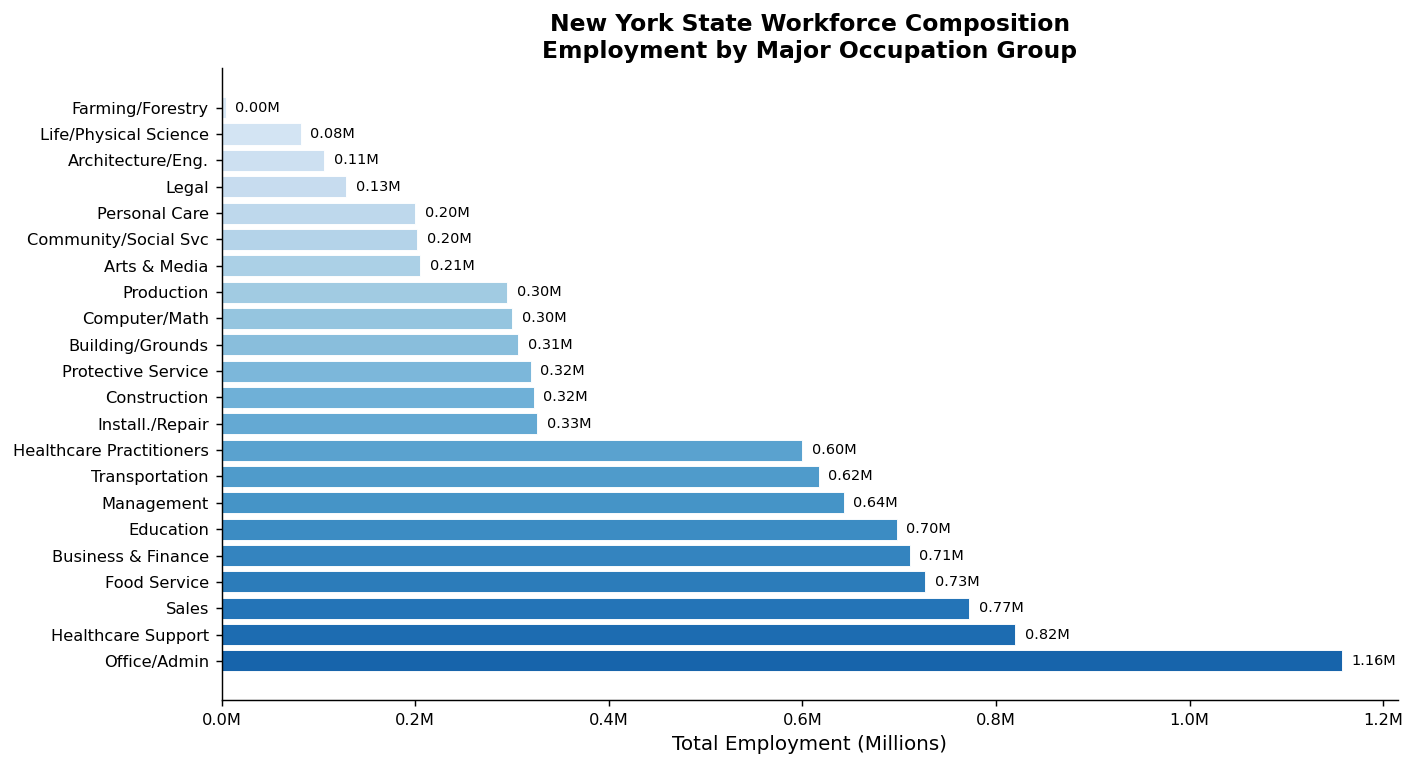


Total NYS workforce: 9,541,850 workers


In [8]:
# ── 3.1  Employment by Major Occupation Group (statewide)
fig, ax = plt.subplots(figsize=(11, 6))

colors = plt.cm.Blues_r(np.linspace(0.2, 0.85, len(major_state)))
bars = ax.barh(major_state['Short_Title'], major_state['Employment'] / 1e6,
               color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, major_state['Employment']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val/1e6:.2f}M', va='center', fontsize=8)

ax.set_xlabel('Total Employment (Millions)')
ax.set_title('New York State Workforce Composition\nEmployment by Major Occupation Group', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}M'))
plt.tight_layout()
plt.show()
print(f"\nTotal NYS workforce: {major_state['Employment'].sum():,.0f} workers")


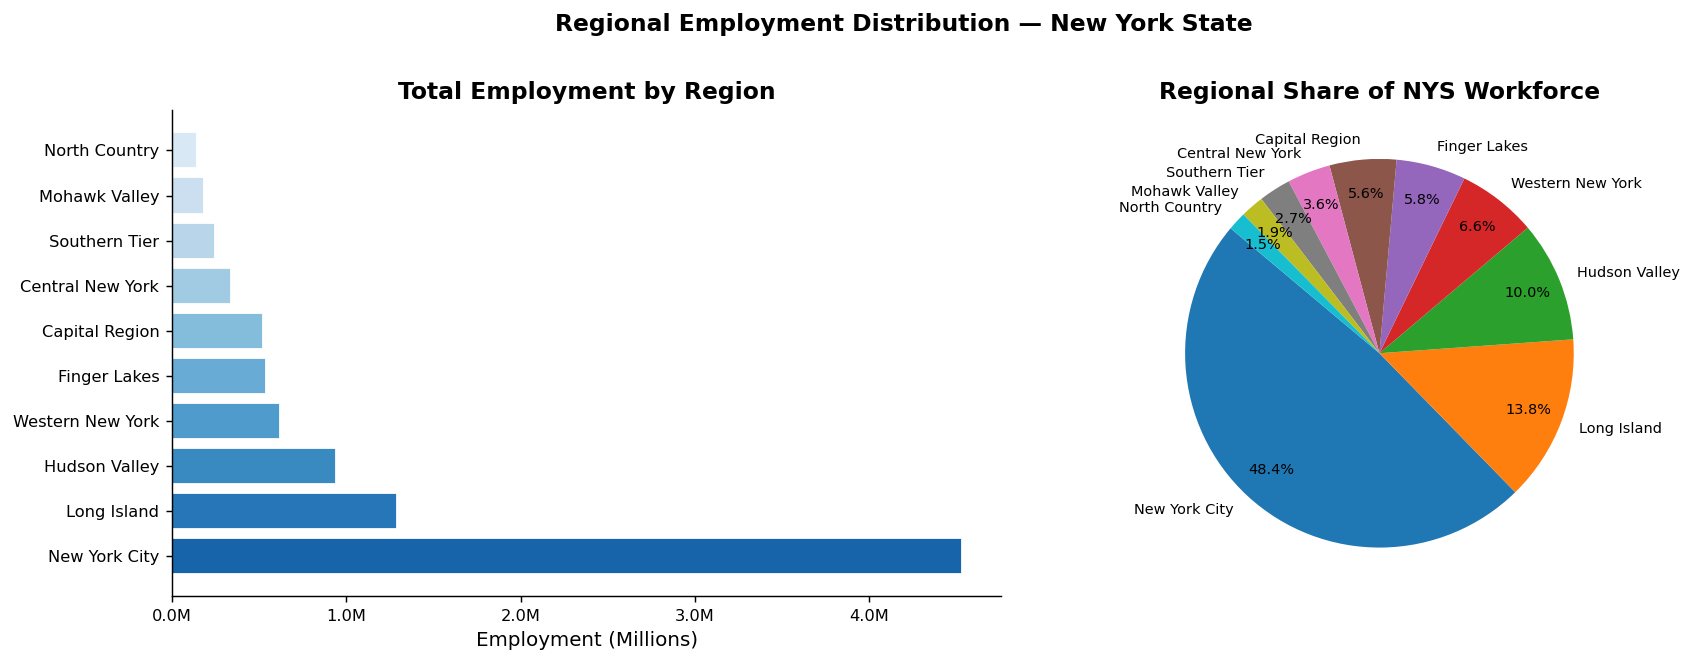

In [9]:
# ── 3.2  Regional Employment Distribution 
reg_total = (df_occ_region[df_occ_region['Is_Major_Group']]
             .groupby('Area Name')['Employment'].sum()
             .sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors_r = plt.cm.Blues_r(np.linspace(0.2, 0.85, len(reg_total)))
axes[0].barh(reg_total.index, reg_total.values / 1e6, color=colors_r, edgecolor='white')
axes[0].set_xlabel('Employment (Millions)')
axes[0].set_title('Total Employment by Region', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}M'))

# Pie chart — share
wedge_colors = plt.cm.tab10(np.linspace(0, 1, len(reg_total)))
axes[1].pie(reg_total.values, labels=reg_total.index,
            autopct='%1.1f%%', colors=wedge_colors,
            startangle=140, pctdistance=0.82,
            textprops={'fontsize': 8})
axes[1].set_title('Regional Share of NYS Workforce', fontweight='bold')

plt.suptitle('Regional Employment Distribution — New York State', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


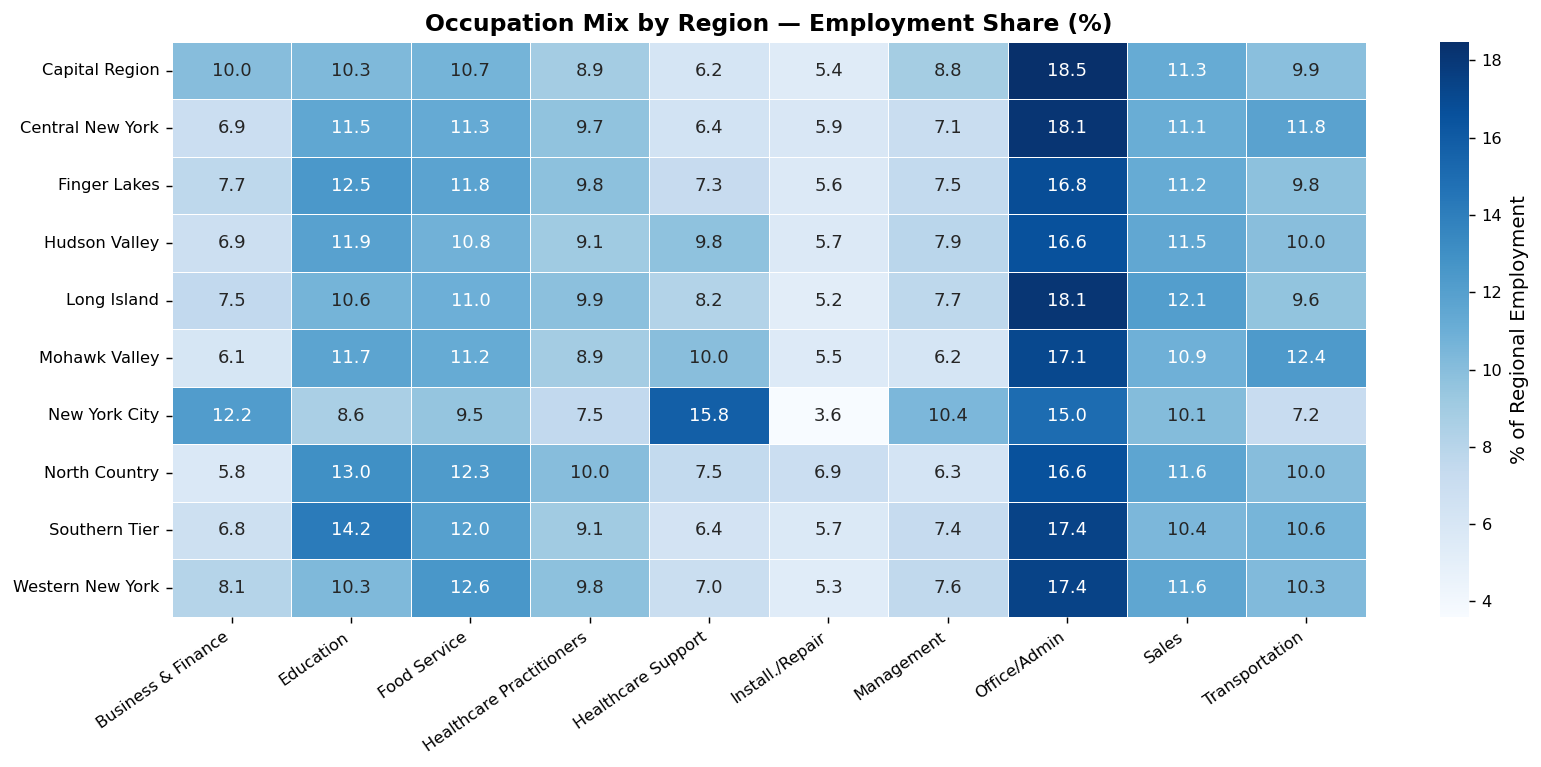

In [10]:
# ── 3.3  Occupation Mix Heatmap by Region 
# Top 10 occupation groups by statewide employment
top10_titles = major_state['Occupational Title'].head(10).tolist()
top10_short  = major_state['Short_Title'].head(10).tolist()

pivot = (df_occ_region[df_occ_region['Occupational Title'].isin(top10_titles)]
         .pivot_table(index='Area Name', columns='Occupational Title',
                      values='Employment', aggfunc='sum'))

# Rename columns to short titles
rename_map = dict(zip(top10_titles, top10_short))
pivot.columns = [rename_map.get(c, c) for c in pivot.columns]

# Normalize row-wise (share within each region)
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(pivot_norm, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.4, ax=ax,
            cbar_kws={'label': '% of Regional Employment'})
ax.set_title('Occupation Mix by Region — Employment Share (%)', fontweight='bold', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()


## 4. Regional Wage Analysis <a id='4'></a>

Examining **how wages differ across New York's regions** — identifying which regions command premium wages and which face wage suppression relative to the state benchmark.


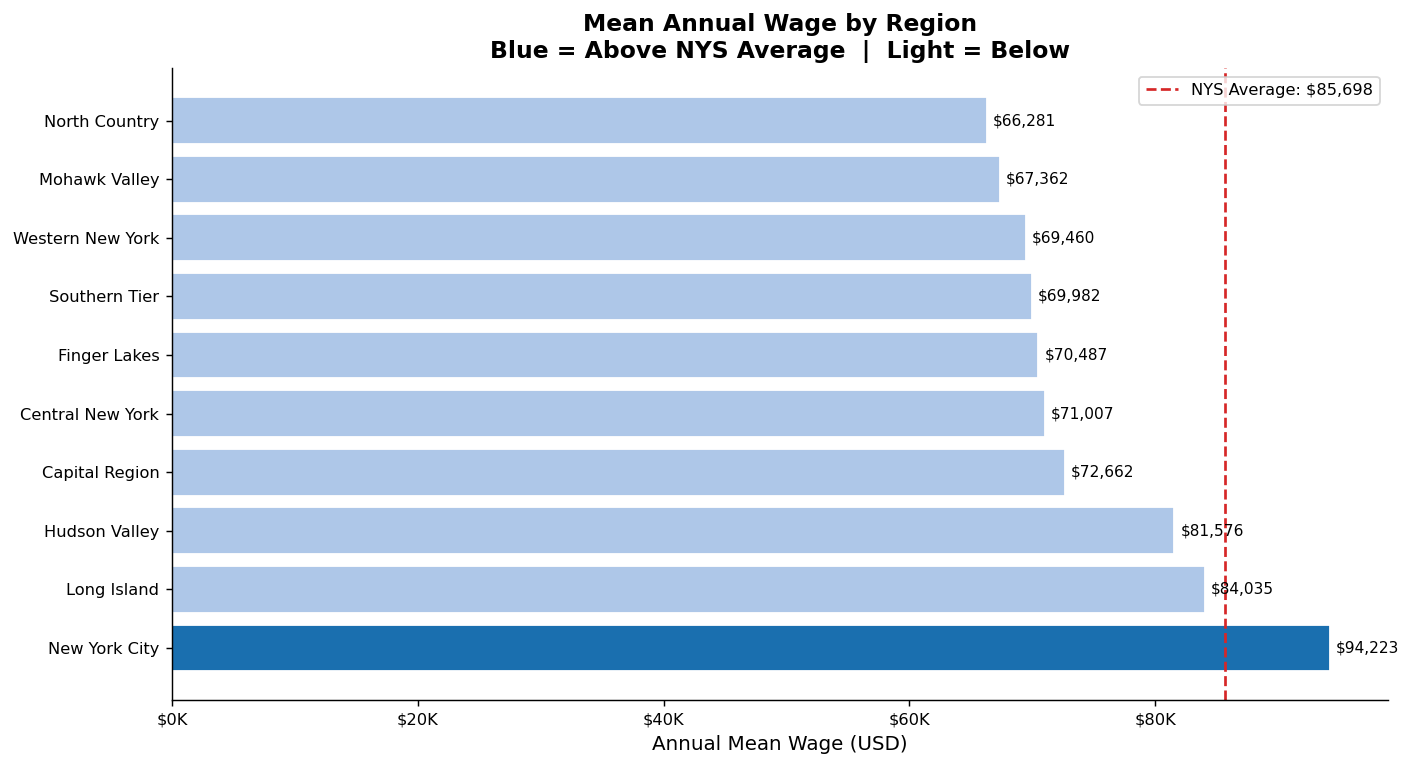

In [ ]:
# ── 4.1  Mean Wage by Region (all occupations) 
reg_wage = (df_occ_region[df_occ_region['Is_Major_Group']]
            .group+++by('Area Name')[['Mean Wage','Median Wage','Entry Wage','Experienced Wage']]
            .mean().round(0).sort_values('Mean Wage', ascending=False))

state_mean = df_occ_state[df_occ_state['Is_Major_Group']]['Mean Wage'].mean()

fig, ax = plt.subplots(figsize=(11, 6))
colors_w = [ACCENT if v > state_mean else '#aec7e8' for v in reg_wage['Mean Wage']]
bars = ax.barh(reg_wage.index, reg_wage['Mean Wage'], color=colors_w, edgecolor='white')
ax.axvline(state_mean, color='#d62728', linestyle='--', linewidth=1.5,
           label=f'NYS Average: ${state_mean:,.0f}')

for bar, val in zip(bars, reg_wage['Mean Wage']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=8.5)

ax.set_xlabel('Annual Mean Wage (USD)')
ax.set_title('Mean Annual Wage by Region\nBlue = Above NYS Average  |  Light = Below', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
ax.legend()
plt.tight_layout()
plt.show()


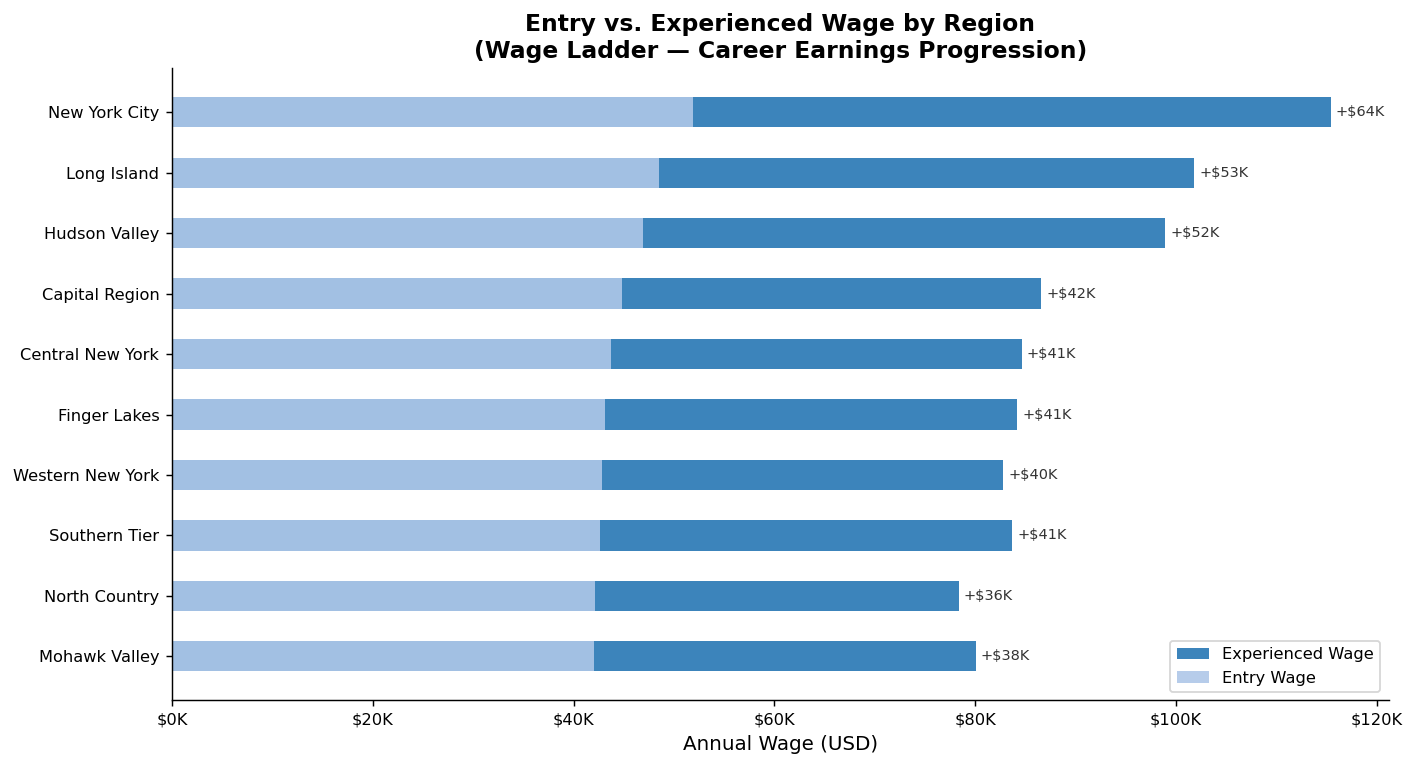

In [12]:
# ── 4.2  Wage Ladder — Entry vs Experienced by Region 
reg_wage_sorted = reg_wage.sort_values('Entry Wage')

fig, ax = plt.subplots(figsize=(11, 6))
y_pos = np.arange(len(reg_wage_sorted))

ax.barh(y_pos, reg_wage_sorted['Experienced Wage'], height=0.5,
        color='#1a6faf', label='Experienced Wage', alpha=0.85)
ax.barh(y_pos, reg_wage_sorted['Entry Wage'], height=0.5,
        color='#aec7e8', label='Entry Wage', alpha=0.9)

ax.set_yticks(y_pos)
ax.set_yticklabels(reg_wage_sorted.index)
ax.set_xlabel('Annual Wage (USD)')
ax.set_title('Entry vs. Experienced Wage by Region\n(Wage Ladder — Career Earnings Progression)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
ax.legend()

# Annotate wage gap
for i, (entry, exp) in enumerate(zip(reg_wage_sorted['Entry Wage'], reg_wage_sorted['Experienced Wage'])):
    gap = exp - entry
    ax.text(exp + 500, i, f'+${gap/1e3:.0f}K', va='center', fontsize=8, color='#333')

plt.tight_layout()
plt.show()


In [13]:
# ── 4.3  Top-Paying Occupations per Region 
detail_region = df_occ_region[~df_occ_region['Is_Major_Group']].copy()

top_occ_per_region = (detail_region
    .sort_values('Mean Wage', ascending=False)
    .groupby('Area Name')
    .head(3)[['Area Name','Occupational Title','Mean Wage','Employment']]
    .reset_index(drop=True))

print("Top 3 Highest-Paying Occupations per Region:")
print(top_occ_per_region.to_string(index=False))


Top 3 Highest-Paying Occupations per Region:
       Area Name                    Occupational Title  Mean Wage  Employment
   North Country                         Cardiologists     547850        20.0
Central New York                         Cardiologists     463150        50.0
   Hudson Valley                         Cardiologists     459835       250.0
     Long Island                         Cardiologists     457538       460.0
   Southern Tier                          Radiologists     454840        60.0
   Southern Tier              Physicians, Pathologists     440582       540.0
   Hudson Valley Orthopedic Surgeons, Except Pediatric     438165       130.0
Western New York                          Radiologists     437535       100.0
   Southern Tier                   Surgeons, All Other     430590       650.0
   New York City                    Pediatric Surgeons     429474       420.0
   Hudson Valley                          Radiologists     428718       230.0
     Long Island   

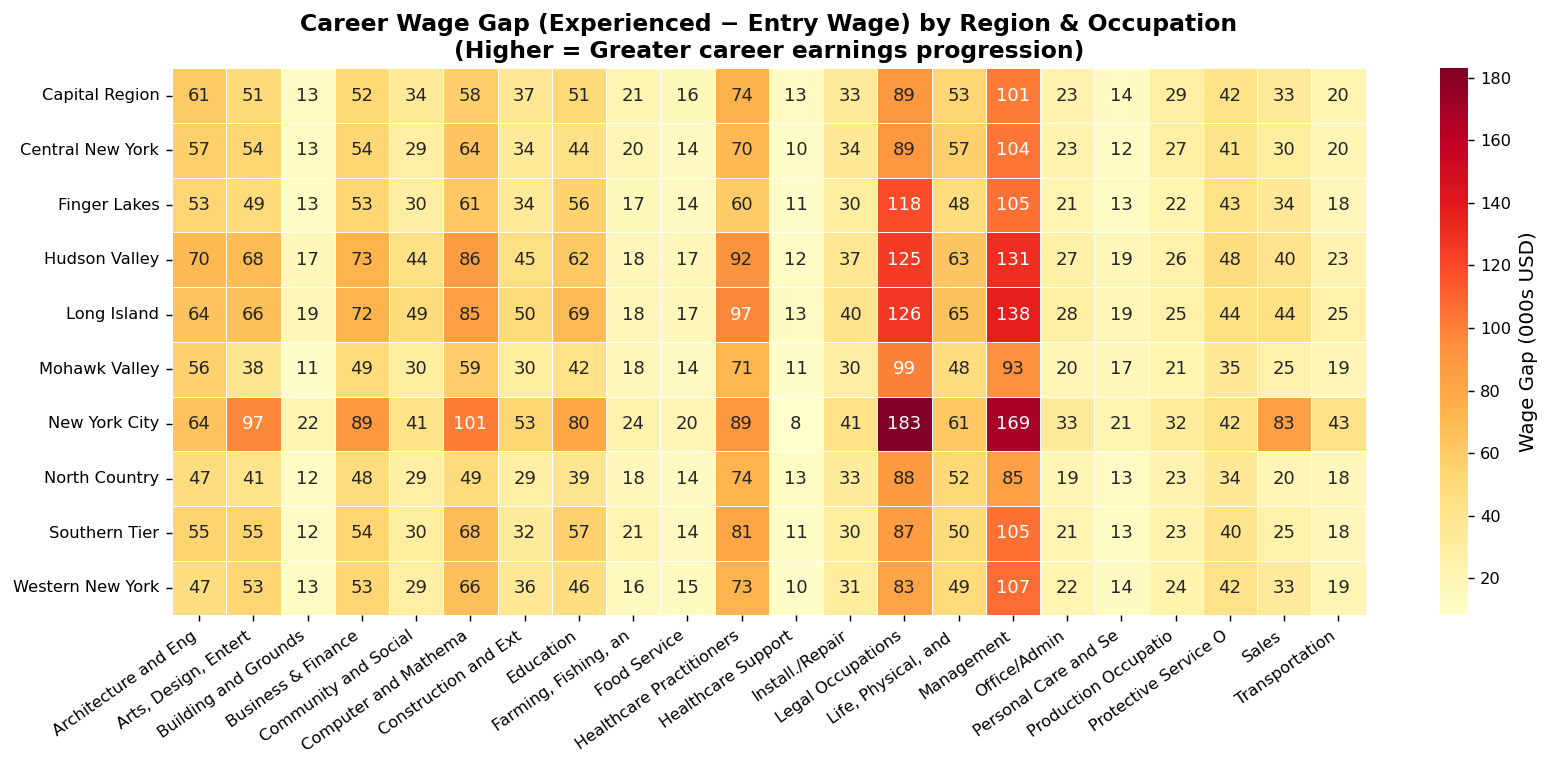

In [14]:
# ── 4.4  Wage Gap (Experienced - Entry) by Occupation Group & Region
wage_gap_pivot = (df_occ_region[df_occ_region['Is_Major_Group']]
                  .pivot_table(index='Area Name', columns='Occupational Title',
                               values='Wage_Gap', aggfunc='mean'))

# Shorten column names
wage_gap_pivot.columns = [rename_map.get(c, c[:20]) for c in wage_gap_pivot.columns]

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(wage_gap_pivot / 1000, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.4, ax=ax,
            cbar_kws={'label': 'Wage Gap (000s USD)'})
ax.set_title('Career Wage Gap (Experienced − Entry Wage) by Region & Occupation\n(Higher = Greater career earnings progression)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()


## 5. Wage Distribution Modeling & Statistical Analysis <a id='5'></a>

Modeling the **shape and dispersion of wage distributions** across occupation groups to understand inequality, skewness, and the statistical properties relevant to compensation policy analysis.


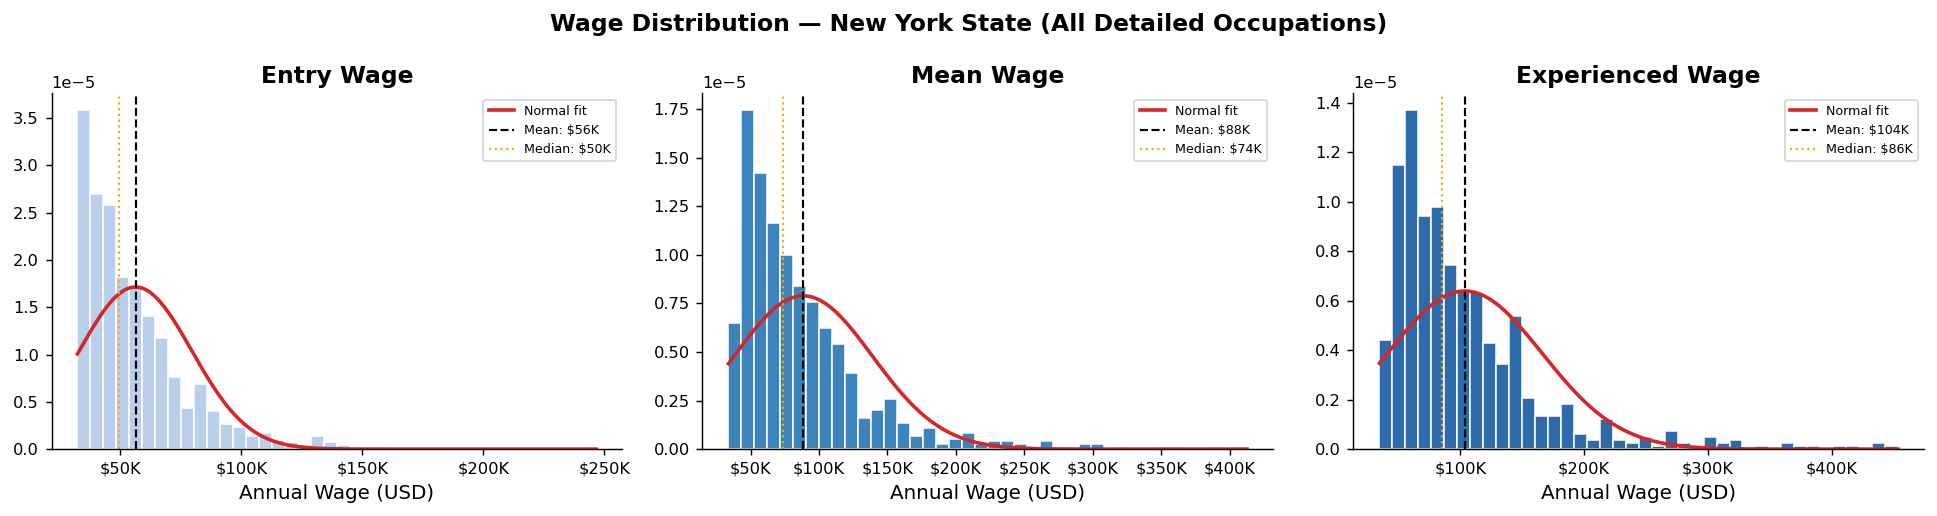


=== Wage Distribution Summary ===
       Entry Wage  Mean Wage  Median Wage  Experienced Wage
count       781.0      781.0        781.0             781.0
mean      56251.0    88441.0      79456.0          103584.0
std       23273.0    50566.0      38740.0           62442.0
min       32240.0    33784.0      32334.0           34625.0
25%       39253.0    54246.0      50790.0           60922.0
50%       49588.0    73509.0      67504.0           85502.0
75%       65285.0   105524.0      97313.0          124111.0
max      246670.0   412754.0     244171.0          453549.0


In [15]:
# ── 5.1  Overall Wage Distribution — NYS Statewide 
detail_state = df_occ_state[~df_occ_state['Is_Major_Group']].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(axes,
                           ['Entry Wage', 'Mean Wage', 'Experienced Wage'],
                           ['#aec7e8', ACCENT, '#08519c']):
    data = detail_state[col].dropna()
    ax.hist(data, bins=40, color=color, alpha=0.85, edgecolor='white', density=True)

    # Fit normal curve
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 300)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color='#d62728', lw=2, label='Normal fit')
    ax.axvline(mu, color='black', linestyle='--', lw=1.2, label=f'Mean: ${mu/1e3:.0f}K')
    ax.axvline(data.median(), color='orange', linestyle=':', lw=1.2,
               label=f'Median: ${data.median()/1e3:.0f}K')

    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Annual Wage (USD)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
    ax.legend(fontsize=7)

plt.suptitle('Wage Distribution — New York State (All Detailed Occupations)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Descriptive stats
print("\n=== Wage Distribution Summary ===")
print(detail_state[['Entry Wage','Mean Wage','Median Wage','Experienced Wage']].describe().round(0))


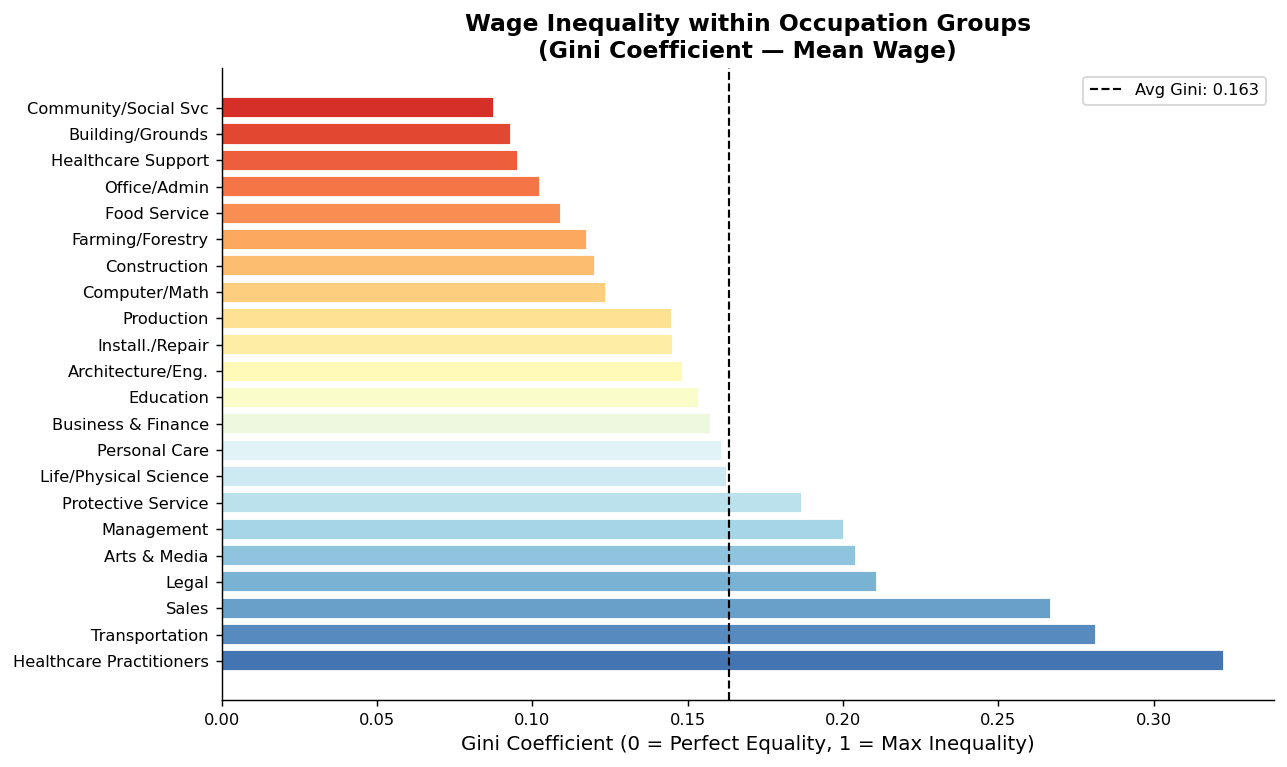


Most unequal occupation groups (highest Gini):
SOC_Major     Gini                    Group
       29 0.322562 Healthcare Practitioners
       53 0.281288           Transportation
       41 0.266889                    Sales
       23 0.210890                    Legal
       27 0.204052             Arts & Media


In [16]:
# ── 5.2  Wage Inequality — Gini Coefficient by Occupation Group 
def gini(arr):
    arr = np.sort(arr[~np.isnan(arr)])
    n = len(arr)
    if n == 0: return np.nan
    idx = np.arange(1, n+1)
    return (2 * np.sum(idx * arr) / (n * np.sum(arr))) - (n + 1) / n

gini_by_group = (detail_state.groupby('SOC_Major')['Mean Wage']
                 .apply(gini).reset_index()
                 .rename(columns={'Mean Wage': 'Gini'}))

# Map SOC prefix to title
soc_title_map = (major_state.set_index('SOC_Major')['Short_Title'].to_dict())
gini_by_group['Group'] = gini_by_group['SOC_Major'].map(soc_title_map).fillna(gini_by_group['SOC_Major'])
gini_by_group = gini_by_group.sort_values('Gini', ascending=False).dropna()

fig, ax = plt.subplots(figsize=(10, 6))
colors_g = plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, len(gini_by_group)))
ax.barh(gini_by_group['Group'], gini_by_group['Gini'], color=colors_g, edgecolor='white')
ax.axvline(gini_by_group['Gini'].mean(), color='black', linestyle='--', lw=1.2,
           label=f"Avg Gini: {gini_by_group['Gini'].mean():.3f}")
ax.set_xlabel('Gini Coefficient (0 = Perfect Equality, 1 = Max Inequality)')
ax.set_title('Wage Inequality within Occupation Groups\n(Gini Coefficient — Mean Wage)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\nMost unequal occupation groups (highest Gini):")
print(gini_by_group.head(5).to_string(index=False))


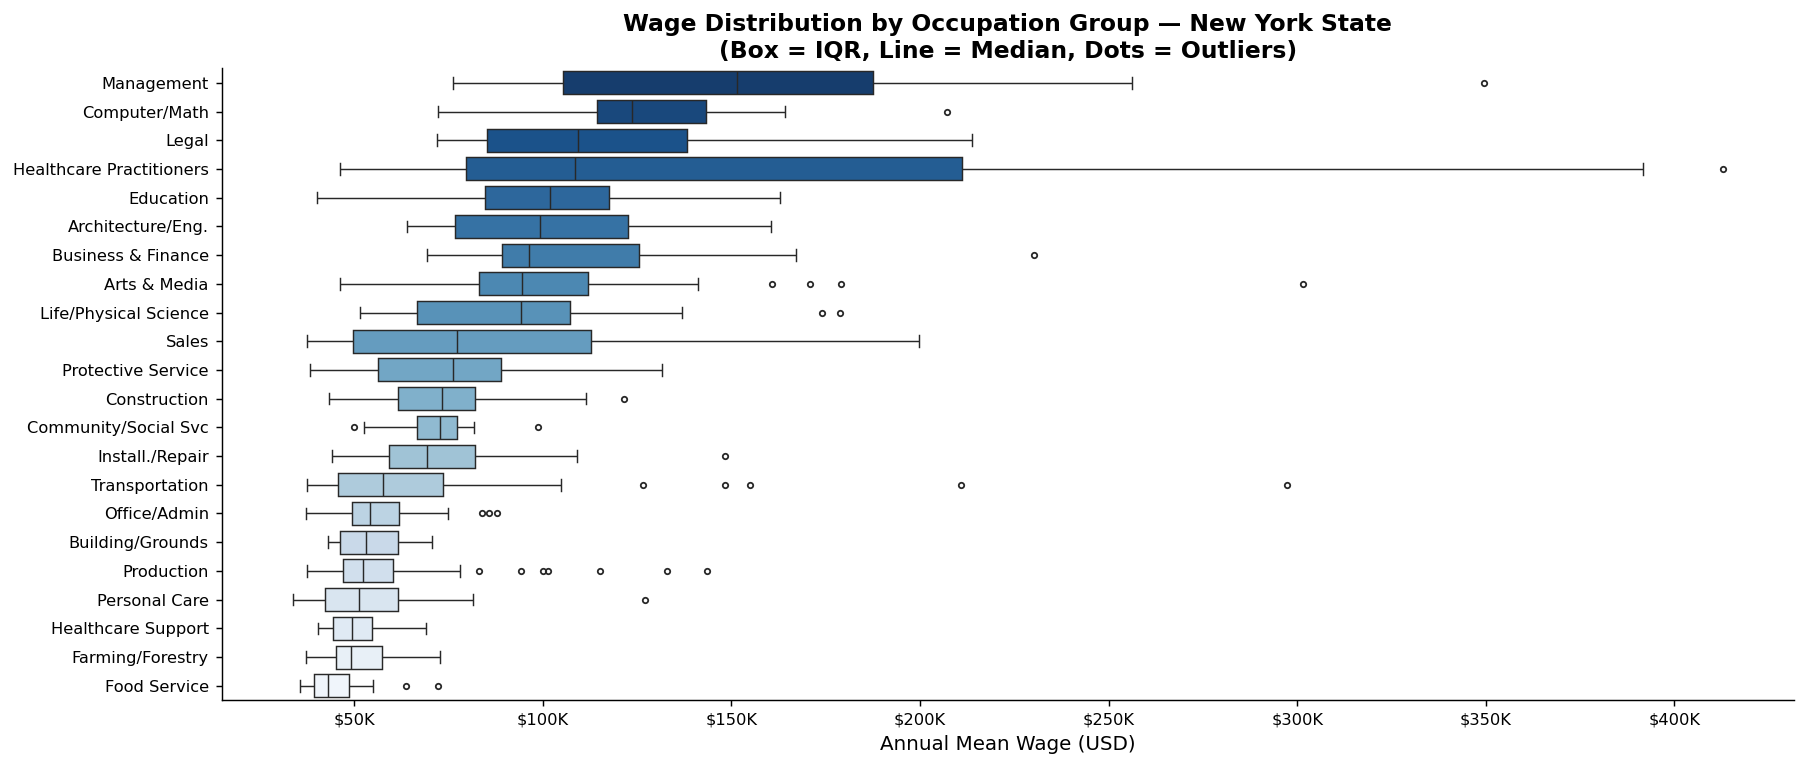

In [17]:
# ── 5.3  Box Plots — Wage Distribution by Major Occupation Group 
plot_data = detail_state.copy()
plot_data['Group'] = plot_data['SOC_Major'].map(soc_title_map).fillna('Other')

# Order by median mean wage
order = (plot_data.groupby('Group')['Mean Wage'].median()
         .sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=plot_data, y='Group', x='Mean Wage', order=order,
            palette='Blues_r', ax=ax, linewidth=0.8, fliersize=3)
ax.set_xlabel('Annual Mean Wage (USD)')
ax.set_ylabel('')
ax.set_title('Wage Distribution by Occupation Group — New York State\n(Box = IQR, Line = Median, Dots = Outliers)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
plt.tight_layout()
plt.show()


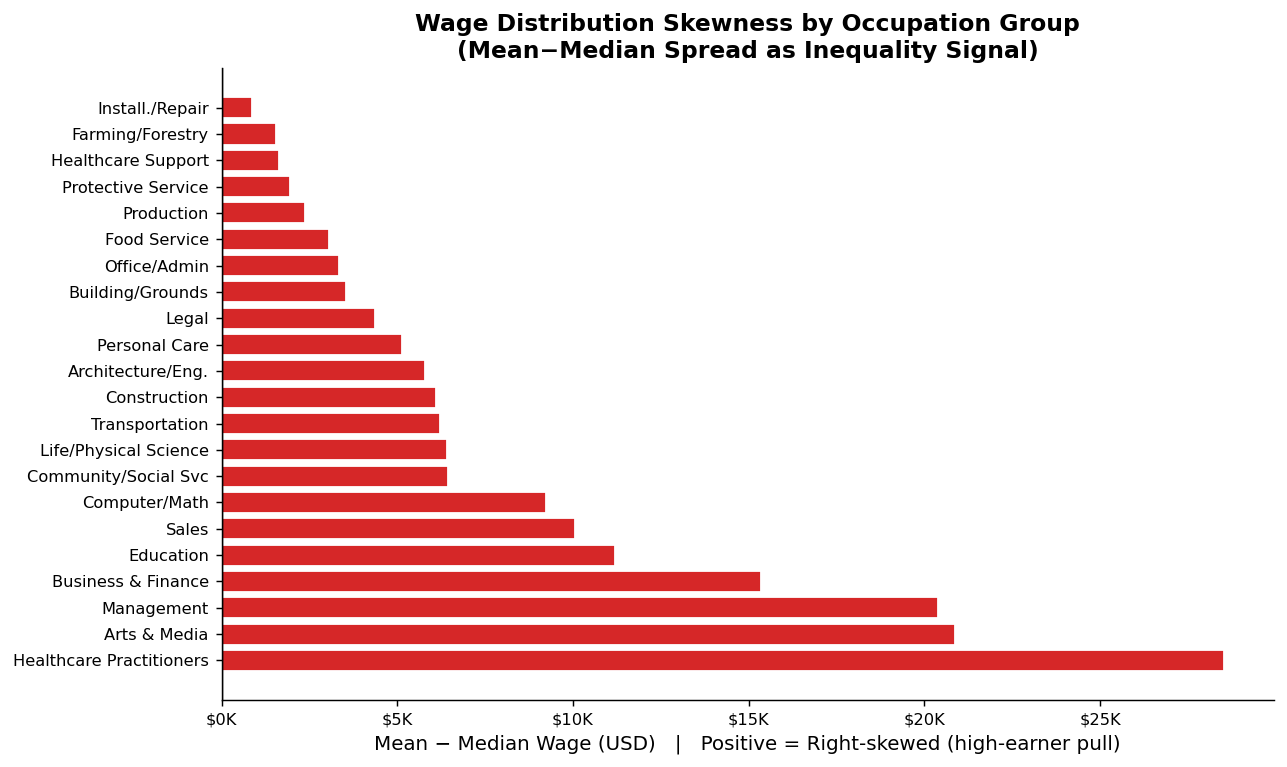


Groups with strongest upward skew (high-earner concentration):
                          Mean Wage  Median Wage   Spread
Group                                                    
Healthcare Practitioners   148930.0     120405.0  28525.0
Arts & Media               104575.0      83716.0  20859.0
Management                 157395.0     136996.0  20398.0
Business & Finance         111415.0      96072.0  15343.0
Education                  100966.0      89781.0  11185.0


In [18]:
# ── 5.4  Mean vs Median Wage Spread — Skewness Indicator
# Large mean-median spread signals right-skewed / high-earner pull
spread_by_group = (plot_data.groupby('Group')[['Mean Wage','Median Wage']]
                   .mean().assign(Spread=lambda d: d['Mean Wage'] - d['Median Wage'])
                   .sort_values('Spread', ascending=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors_s = ['#d62728' if s > 0 else '#1a6faf' for s in spread_by_group['Spread']]
ax.barh(spread_by_group.index, spread_by_group['Spread'], color=colors_s, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean − Median Wage (USD)   |   Positive = Right-skewed (high-earner pull)')
ax.set_title('Wage Distribution Skewness by Occupation Group\n(Mean−Median Spread as Inequality Signal)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
plt.tight_layout()
plt.show()

print("\nGroups with strongest upward skew (high-earner concentration):")
print(spread_by_group.head(5)[['Mean Wage','Median Wage','Spread']].round(0))


## 6. Regression Analysis — Wage Determinants <a id='6'></a>

Applying **OLS multiple regression** to identify which factors — occupation group, region, and employment size — are statistically significant predictors of mean wages. This mirrors the methodology used in **policy-relevant wage research**.


In [19]:
# ── 6.1  Feature Engineering for Regression 
reg_df = df_occ_region[~df_occ_region['Is_Major_Group']].copy()
reg_df = reg_df.dropna(subset=['Mean Wage','Employment','Entry Wage','Experienced Wage'])

le = LabelEncoder()
reg_df['Region_Code']    = le.fit_transform(reg_df['Area Name'])
reg_df['SOC_Major_Code'] = le.fit_transform(reg_df['SOC_Major'])
reg_df['Log_Employment'] = np.log1p(reg_df['Employment'])
reg_df['Log_Mean_Wage']  = np.log(reg_df['Mean Wage'])

print("Regression dataset shape:", reg_df.shape)
reg_df[['Area Name','Occupational Title','Mean Wage','Employment',
        'Region_Code','SOC_Major_Code','Log_Employment']].head()


Regression dataset shape: (6025, 20)


,Area Name,Occupational Title,Mean Wage,Employment,Region_Code,SOC_Major_Code,Log_Employment
806,Capital Region,Chief Executives,196059,680.0,0,0,6.523562
807,Capital Region,General and Operations Managers,135584,11200.0,0,0,9.323758
808,Capital Region,Legislators,136546,410.0,0,0,6.018593
809,Capital Region,Advertising and Promotions Managers,178260,70.0,0,0,4.262680
810,Capital Region,Marketing Managers,163407,1090.0,0,0,6.994850


In [20]:
# ── 6.2  OLS Regression — Mean Wage Determinants 
X_vars = ['Entry Wage', 'Wage_Gap', 'Log_Employment', 'Region_Code', 'SOC_Major_Code']
X = reg_df[X_vars]
y = reg_df['Mean Wage']

X_sm = sm.add_constant(X)
ols_model = sm.OLS(y, X_sm).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:              Mean Wage   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                 4.566e+04
Date:                Tue, 26 May 2026   Prob (F-statistic):               0.00
Time:                        01:32:46   Log-Likelihood:                -62750.
No. Observations:                6025   AIC:                         1.255e+05
Df Residuals:                    6019   BIC:                         1.256e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          -1.135e+04    593.356    -19.

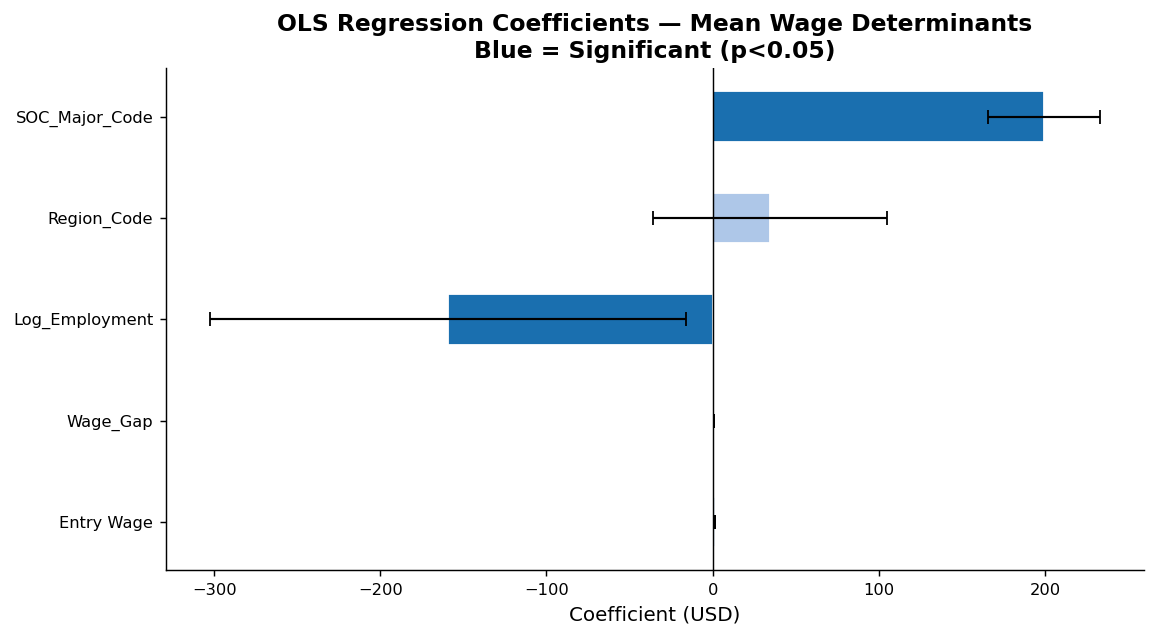


Model R²: 0.9743
Adj R² : 0.9743
F-stat  : 45655.90  (p=0.00e+00)


In [21]:
# ── 6.3  Coefficient Plot 
coef = ols_model.params.drop('const')
ci   = ols_model.conf_int().drop('const')
pval = ols_model.pvalues.drop('const')

colors_c = ['#1a6faf' if p < 0.05 else '#aec7e8' for p in pval]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(coef.index, coef.values, color=colors_c, edgecolor='white', height=0.5)
ax.errorbar(coef.values, coef.index, 
            xerr=[(coef - ci[0]).values, (ci[1] - coef).values],
            fmt='none', color='black', capsize=4, linewidth=1.2)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (USD)')
ax.set_title('OLS Regression Coefficients — Mean Wage Determinants\nBlue = Significant (p<0.05)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nModel R²: {ols_model.rsquared:.4f}")
print(f"Adj R² : {ols_model.rsquared_adj:.4f}")
print(f"F-stat  : {ols_model.fvalue:.2f}  (p={ols_model.f_pvalue:.2e})")


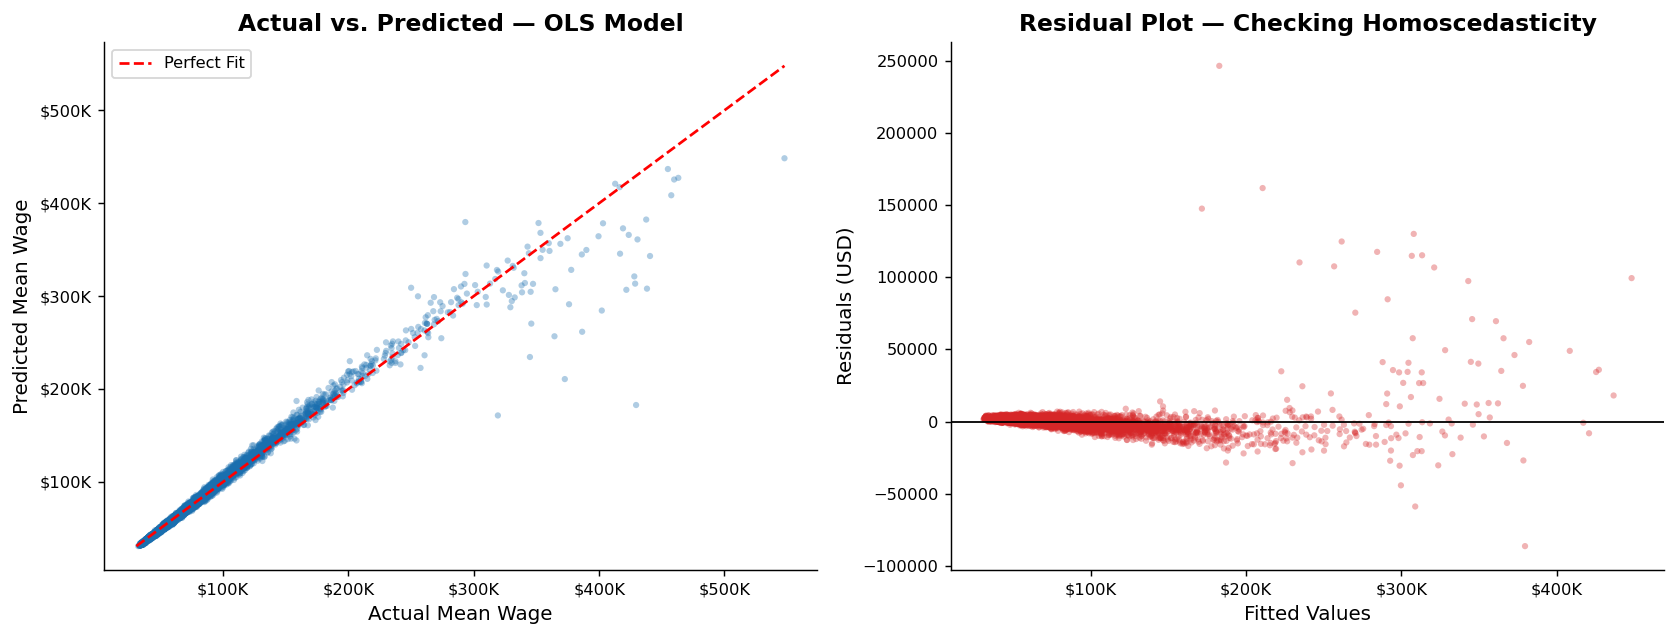

In [22]:
# ── 6.4  Actual vs Predicted + Residual Plot 
y_pred = ols_model.fittedvalues
residuals = ols_model.resid

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(y, y_pred, alpha=0.35, color=ACCENT, s=12, edgecolors='none')
lim = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
axes[0].plot(lim, lim, 'r--', lw=1.5, label='Perfect Fit')
axes[0].set_xlabel('Actual Mean Wage')
axes[0].set_ylabel('Predicted Mean Wage')
axes[0].set_title('Actual vs. Predicted — OLS Model', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[0].legend()

# Residuals
axes[1].scatter(y_pred, residuals, alpha=0.35, color='#d62728', s=12, edgecolors='none')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals (USD)')
axes[1].set_title('Residual Plot — Checking Homoscedasticity', fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))

plt.tight_layout()
plt.show()


## 7. Statistical Hypothesis Testing <a id='7'></a>

Applying rigorous **statistical tests** to validate observed wage differences — both between regions and between occupation groups — providing a defensible analytical basis for policy findings.


In [ ]:
# ── 7.1  Normality Test on Wage Distributions
print("=== D'Agostino-Pearson Normality Test (H₀: distribution is normal) ===\n")
for col in ['Entry Wage', 'Mean Wage', 'Experienced Wage']:
    data = detail_state[col].dropna()
    stat, p = normaltest(data)
    result = "REJECT H₀ (not normal)" if p < 0.05 else "FAIL to reject H₀ (normal)"
    print(f"{col:<20} | statistic={stat:.2f} | p={p:.2e} → {result}")


=== D'Agostino-Pearson Normality Test (H₀: distribution is normal) ===

Entry Wage           | statistic=392.58 | p=5.65e-86 → REJECT H₀ (not normal)
Mean Wage            | statistic=417.19 | p=2.55e-91 → REJECT H₀ (not normal)
Experienced Wage     | statistic=391.18 | p=1.14e-85 → REJECT H₀ (not normal)


=== Mann-Whitney U Test ===
H₀: NYC wage distribution = Rest-of-State wage distribution
NYC Mean Wage       : $97,896
Rest-of-State Mean  : $80,088
U statistic         : 2393866.00
p-value             : 3.6289e-24
Result              : REJECT H₀ — statistically significant wage gap


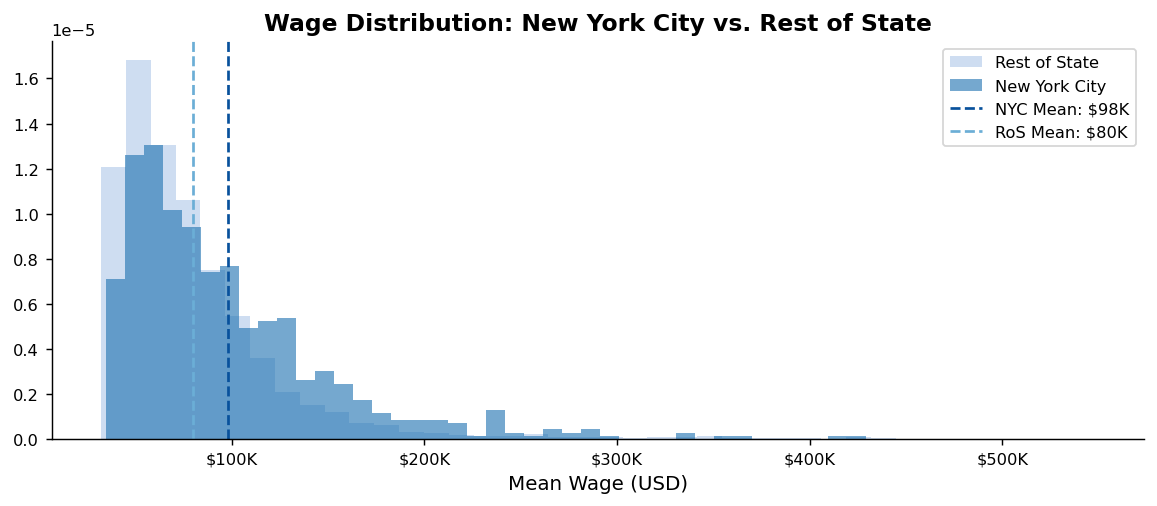

In [ ]:
# ── 7.2  Mann-Whitney U — NYC vs Rest of State 
nyc_wages  = df_occ_region[df_occ_region['Area Name'] == 'New York City']['Mean Wage'].dropna()
rest_wages = df_occ_region[df_occ_region['Area Name'] != 'New York City']['Mean Wage'].dropna()

stat, p = mannwhitneyu(nyc_wages, rest_wages, alternative='two-sided')

print("=== Mann-Whitney U Test ===")
print("H₀: NYC wage distribution = Rest-of-State wage distribution")
print(f"NYC Mean Wage       : ${nyc_wages.mean():,.0f}")
print(f"Rest-of-State Mean  : ${rest_wages.mean():,.0f}")
print(f"U statistic         : {stat:.2f}")
print(f"p-value             : {p:.4e}")
print(f"Result              : {'REJECT H₀ — statistically significant wage gap' if p < 0.05 else 'FAIL to reject H₀'}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(rest_wages, bins=40, alpha=0.6, color='#aec7e8', label='Rest of State', density=True)
ax.hist(nyc_wages,  bins=40, alpha=0.6, color=ACCENT,    label='New York City', density=True)
ax.axvline(nyc_wages.mean(),  color='#08519c', linestyle='--', lw=1.5, label=f'NYC Mean: ${nyc_wages.mean()/1e3:.0f}K')
ax.axvline(rest_wages.mean(), color='#6baed6', linestyle='--', lw=1.5, label=f'RoS Mean: ${rest_wages.mean()/1e3:.0f}K')
ax.set_xlabel('Mean Wage (USD)')
ax.set_title('Wage Distribution: New York City vs. Rest of State', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
ax.legend()
plt.tight_layout()
plt.show()


In [25]:
# ── 7.3  Kruskal-Wallis — Wage Differences Across All Regions
region_groups = [grp['Mean Wage'].dropna().values 
                 for _, grp in df_occ_region.groupby('Area Name')]

stat_kw, p_kw = kruskal(*region_groups)

print("=== Kruskal-Wallis H Test ===")
print("H₀: Median wages are equal across all regions")
print(f"H statistic : {stat_kw:.2f}")
print(f"p-value     : {p_kw:.4e}")
print(f"Result      : {'REJECT H₀ — significant wage variation across regions' if p_kw < 0.05 else 'FAIL to reject H₀'}")

# Effect size (eta squared)
n_total = sum(len(g) for g in region_groups)
eta_sq = (stat_kw - len(region_groups) + 1) / (n_total - len(region_groups))
print(f"Effect size (η²) : {eta_sq:.4f}  ({'Large' if eta_sq > 0.14 else 'Medium' if eta_sq > 0.06 else 'Small'})")


=== Kruskal-Wallis H Test ===
H₀: Median wages are equal across all regions
H statistic : 262.66
p-value     : 2.1094e-51
Result      : REJECT H₀ — significant wage variation across regions
Effect size (η²) : 0.0407  (Small)


In [26]:
# ── 7.4  Pairwise Region Wage Comparison (Post-hoc) 
from itertools import combinations

regions = df_occ_region['Area Name'].unique()
results_ph = []

for r1, r2 in combinations(regions, 2):
    g1 = df_occ_region[df_occ_region['Area Name'] == r1]['Mean Wage'].dropna()
    g2 = df_occ_region[df_occ_region['Area Name'] == r2]['Mean Wage'].dropna()
    stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
    results_ph.append({'Region A': r1, 'Region B': r2, 'U-stat': round(stat,0), 'p-value': round(p,4),
                       'Significant': 'Yes' if p < 0.05 else 'No',
                       'Median A': g1.median(), 'Median B': g2.median()})

ph_df = pd.DataFrame(results_ph)
sig_pairs = ph_df[ph_df['Significant'] == 'Yes']
print(f"Total region pairs tested : {len(ph_df)}")
print(f"Statistically significant  : {len(sig_pairs)} ({len(sig_pairs)/len(ph_df)*100:.0f}%)")
print("\nAll pairwise results:")
print(ph_df[['Region A','Region B','p-value','Significant']].to_string(index=False))


Total region pairs tested : 45
Statistically significant  : 31 (69%)

All pairwise results:
        Region A         Region B  p-value Significant
  Capital Region Central New York   0.1478          No
  Capital Region     Finger Lakes   0.0275         Yes
  Capital Region    Hudson Valley   0.0000         Yes
  Capital Region      Long Island   0.0000         Yes
  Capital Region    Mohawk Valley   0.0002         Yes
  Capital Region    New York City   0.0000         Yes
  Capital Region    North Country   0.0004         Yes
  Capital Region    Southern Tier   0.0390         Yes
  Capital Region Western New York   0.1256          No
Central New York     Finger Lakes   0.4746          No
Central New York    Hudson Valley   0.0000         Yes
Central New York      Long Island   0.0000         Yes
Central New York    Mohawk Valley   0.0215         Yes
Central New York    New York City   0.0000         Yes
Central New York    North Country   0.0371         Yes
Central New York    Southern

In [27]:
# ── 7.5  High-Wage vs Low-Wage Occupation Group Comparison 
top_groups    = major_state['Occupational Title'].head(3).tolist()   # Top 3 by mean wage
bottom_groups = major_state['Occupational Title'].tail(3).tolist()   # Bottom 3 by mean wage

high_wages = detail_state[detail_state['SOC_Major'].isin(
    major_state[major_state['Occupational Title'].isin(top_groups)]['SOC_Major'])]['Mean Wage'].dropna()
low_wages  = detail_state[detail_state['SOC_Major'].isin(
    major_state[major_state['Occupational Title'].isin(bottom_groups)]['SOC_Major'])]['Mean Wage'].dropna()

stat_hl, p_hl = mannwhitneyu(high_wages, low_wages, alternative='greater')
print("=== High-Wage vs Low-Wage Occupation Groups ===")
print(f"High-wage groups (top 3 by mean): {top_groups}")
print(f"Low-wage  groups (bot 3 by mean): {bottom_groups}")
print(f"High-wage median : ${high_wages.median():,.0f}")
print(f"Low-wage  median : ${low_wages.median():,.0f}")
print(f"Mann-Whitney p   : {p_hl:.4e}")
print(f"Result           : {'Significantly higher wages in top groups' if p_hl < 0.05 else 'No significant difference'}")


=== High-Wage vs Low-Wage Occupation Groups ===
High-wage groups (top 3 by mean): ['Office and Administrative Support Occupations', 'Healthcare Support Occupations', 'Sales and Related Occupations']
Low-wage  groups (bot 3 by mean): ['Architecture and Engineering Occupations', 'Life, Physical, and Social Science Occupations', 'Farming, Fishing, and Forestry Occupations']
High-wage median : $54,512
Low-wage  median : $89,935
Mann-Whitney p   : 1.0000e+00
Result           : No significant difference


## 8. Anomaly Detection — Compensation Outliers & Compliance Signals <a id='8'></a>

Using **statistical methods and Isolation Forest** to flag occupations with anomalous wage structures — a critical step in workforce compliance analysis and detecting potential data quality or reporting issues.


In [28]:
# ── 8.1  Z-Score Based Outlier Detection — Mean Wage 
detail_state['Z_Mean_Wage'] = np.abs(stats.zscore(detail_state['Mean Wage'].fillna(detail_state['Mean Wage'].median())))
detail_state['Z_Wage_Gap']  = np.abs(stats.zscore(detail_state['Wage_Gap'].fillna(detail_state['Wage_Gap'].median())))

threshold = 2.5
outliers_z = detail_state[detail_state['Z_Mean_Wage'] > threshold].copy()

print(f"Z-score threshold  : |Z| > {threshold}")
print(f"Anomalous records  : {len(outliers_z)} of {len(detail_state)} ({len(outliers_z)/len(detail_state)*100:.1f}%)")
print("\nTop anomalous occupations by Mean Wage (Z-score):")
print(outliers_z[['Occupational Title','Mean Wage','Z_Mean_Wage','Wage_Gap']]
      .sort_values('Z_Mean_Wage', ascending=False).head(10).to_string(index=False))


Z-score threshold  : |Z| > 2.5
Anomalous records  : 25 of 781 (3.2%)

Top anomalous occupations by Mean Wage (Z-score):
                            Occupational Title  Mean Wage  Z_Mean_Wage  Wage_Gap
                            Pediatric Surgeons     412754     6.417707 -166834.0
                                 Cardiologists     391687     6.000820  282100.0
            Ophthalmologists, Except Pediatric     358083     5.335842  187910.0
                              Chief Executives     349390     5.163820  312476.0
                                  Radiologists     321645     4.614784  355565.0
                                Dermatologists     305342     4.292170  255964.0
      News Analysts, Reporters, and Journalist     301408     4.214321  360612.0
         Orthopedic Surgeons, Except Pediatric     297779     4.142508  322677.0
Airline Pilots, Copilots, and Flight Engineers     297222     4.131486  244165.0
               Obstetricians and Gynecologists     282189     3.834003

In [29]:
# ── 8.2  Isolation Forest — Multivariate Anomaly Detection 
features = ['Mean Wage', 'Entry Wage', 'Experienced Wage', 'Wage_Gap', 'Log_Employment']
iso_df = detail_state[features + ['Occupational Title','SOC_Major']].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(iso_df[features])

iso_forest = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
iso_forest.fit(X_scaled)
iso_df['Anomaly_Score'] = iso_forest.decision_function(X_scaled)
iso_df['Is_Anomaly']    = iso_forest.predict(X_scaled)   # -1 = anomaly, 1 = normal

anomalies = iso_df[iso_df['Is_Anomaly'] == -1].copy()
print(f"Isolation Forest detected {len(anomalies)} anomalies ({len(anomalies)/len(iso_df)*100:.1f}%)")
print("\nSample anomalous occupations:")
print(anomalies[['Occupational Title','Mean Wage','Entry Wage','Experienced Wage','Wage_Gap']]
      .sort_values('Mean Wage', ascending=False).head(10).to_string(index=False))


Isolation Forest detected 39 anomalies (5.0%)

Sample anomalous occupations:
                            Occupational Title  Mean Wage  Entry Wage  Experienced Wage  Wage_Gap
                            Pediatric Surgeons     412754      246670           79836.0 -166834.0
                                 Cardiologists     391687      153406          435506.0  282100.0
            Ophthalmologists, Except Pediatric     358083      133830          321740.0  187910.0
                              Chief Executives     349390      141073          453549.0  312476.0
                                  Radiologists     321645       84602          440167.0  355565.0
                                Dermatologists     305342      134699          390663.0  255964.0
      News Analysts, Reporters, and Journalist     301408       61000          421612.0  360612.0
         Orthopedic Surgeons, Except Pediatric     297779       82661          405338.0  322677.0
Airline Pilots, Copilots, and Flight Engi

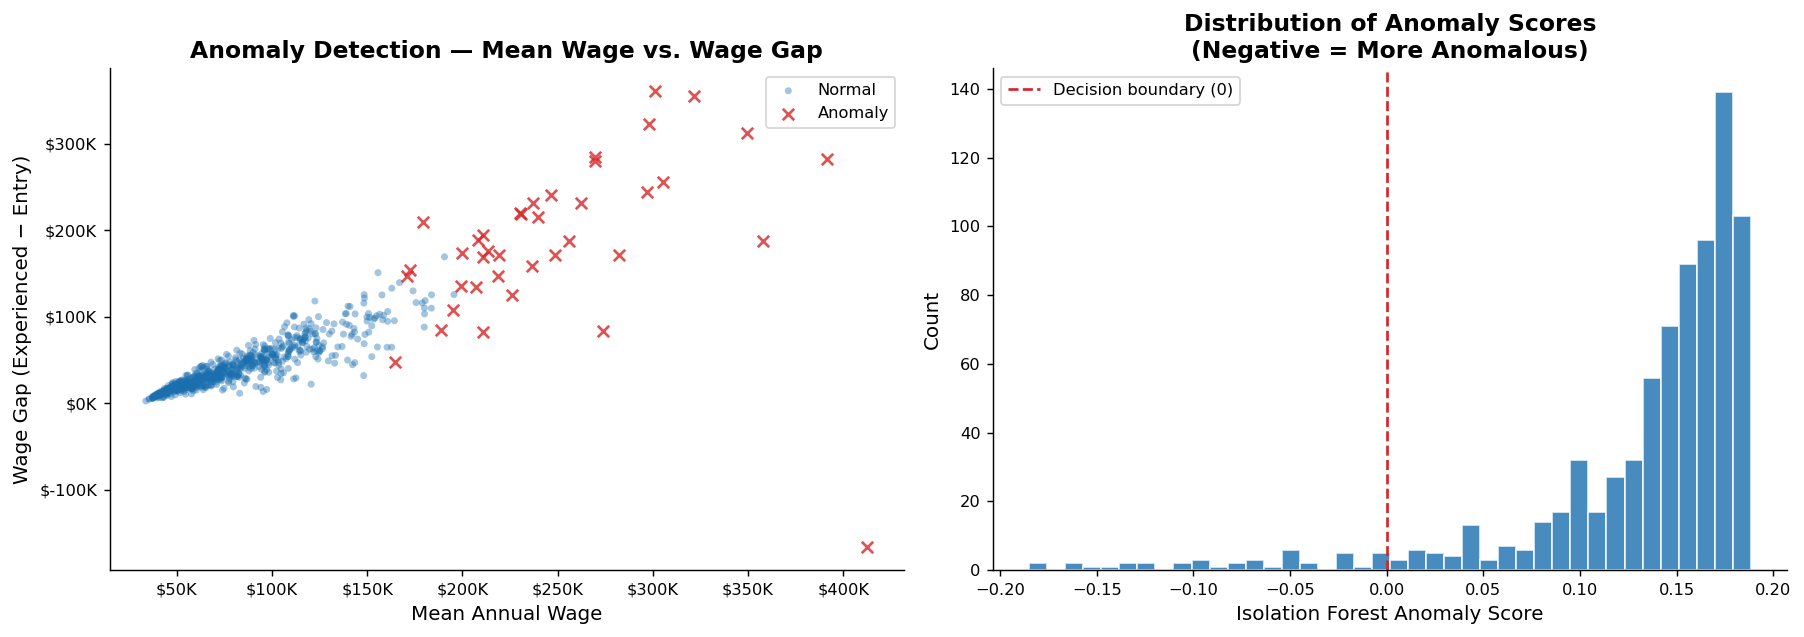

In [30]:
# ── 8.3  Anomaly Visualization — Wage Space 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean Wage vs Wage Gap — colored by anomaly
normal_pts  = iso_df[iso_df['Is_Anomaly'] ==  1]
anomaly_pts = iso_df[iso_df['Is_Anomaly'] == -1]

axes[0].scatter(normal_pts['Mean Wage'],  normal_pts['Wage_Gap'],
                alpha=0.4, color=ACCENT, s=15, label='Normal', edgecolors='none')
axes[0].scatter(anomaly_pts['Mean Wage'], anomaly_pts['Wage_Gap'],
                alpha=0.8, color='#d62728', s=40, label='Anomaly', marker='x', linewidths=1.5)
axes[0].set_xlabel('Mean Annual Wage')
axes[0].set_ylabel('Wage Gap (Experienced − Entry)')
axes[0].set_title('Anomaly Detection — Mean Wage vs. Wage Gap', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[0].legend()

# Anomaly score distribution
axes[1].hist(iso_df['Anomaly_Score'], bins=40, color=ACCENT, alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='#d62728', linestyle='--', lw=1.5, label='Decision boundary (0)')
axes[1].set_xlabel('Isolation Forest Anomaly Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Anomaly Scores\n(Negative = More Anomalous)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


In [31]:
# ── 8.4  IQR-Based Wage Suppression Detector 
# Flag occupations where Mean Wage < Q1 within their SOC major group
# (potential under-compensation relative to peers)

detail_state['Group'] = detail_state['SOC_Major'].map(soc_title_map).fillna('Other')

q1_by_group = detail_state.groupby('Group')['Mean Wage'].transform('quantile', 0.25)
detail_state['Below_Q1'] = detail_state['Mean Wage'] < q1_by_group

suppressed = detail_state[detail_state['Below_Q1']].copy()
print(f"Occupations flagged as potentially wage-suppressed (below Q1 in peer group): {len(suppressed)}")
print("\nSample — potentially under-compensated relative to occupation group peers:")
print(suppressed[['Group','Occupational Title','Mean Wage','Entry Wage']]
      .sort_values('Mean Wage').head(12).to_string(index=False))


Occupations flagged as potentially wage-suppressed (below Q1 in peer group): 197

Sample — potentially under-compensated relative to occupation group peers:
           Group                                   Occupational Title  Mean Wage  Entry Wage
   Personal Care                                           Shampooers      33784       32240
   Personal Care                          Manicurists and Pedicurists      35385       32353
    Food Service                                     Cooks, Fast Food      35678       32519
    Office/Admin Office and Administrative Support Workers, All Other      37219       32330
Farming/Forestry                                              Fallers      37332       33710
    Food Service                        Fast Food and Counter Workers      37336       33405
           Sales                                             Cashiers      37422       32561
  Transportation                               Parking Lot Attendants      37468       33742
      

## 9. Compliance Pattern Assessment <a id='9'></a>

Simulating a **compliance-oriented analytical workflow** to assess whether wage structures in public data reveal patterns consistent with labor standards violations, pay equity concerns, or enforcement priority signals.


In [32]:
# ── 9.1  Wage Floor Compliance Check 
# NYS minimum wage context: $16.00/hr = ~$33,280/yr (NYC), $15.00/hr = ~$31,200/yr (rest)
NYC_MIN_ANNUAL  = 33280
REST_MIN_ANNUAL = 31200

def compliance_flag(row):
    region = row.get('Area Name','')
    wage   = row['Entry Wage']
    floor  = NYC_MIN_ANNUAL if region == 'New York City' else REST_MIN_ANNUAL
    if wage < floor:
        return 'POTENTIAL VIOLATION'
    elif wage < floor * 1.10:
        return 'NEAR FLOOR — Monitor'
    else:
        return 'Compliant'

df_compliance = df_occ_region[~df_occ_region['Is_Major_Group']].copy()
df_compliance['Compliance_Flag'] = df_compliance.apply(compliance_flag, axis=1)

flag_summary = df_compliance['Compliance_Flag'].value_counts()
print("=== Wage Floor Compliance Summary ===")
print(flag_summary)
print(f"\nCompliance rate: {flag_summary.get('Compliant',0)/len(df_compliance)*100:.1f}%")


=== Wage Floor Compliance Summary ===
Compliance_Flag
Compliant               5322
NEAR FLOOR — Monitor     703
Name: count, dtype: int64

Compliance rate: 88.3%


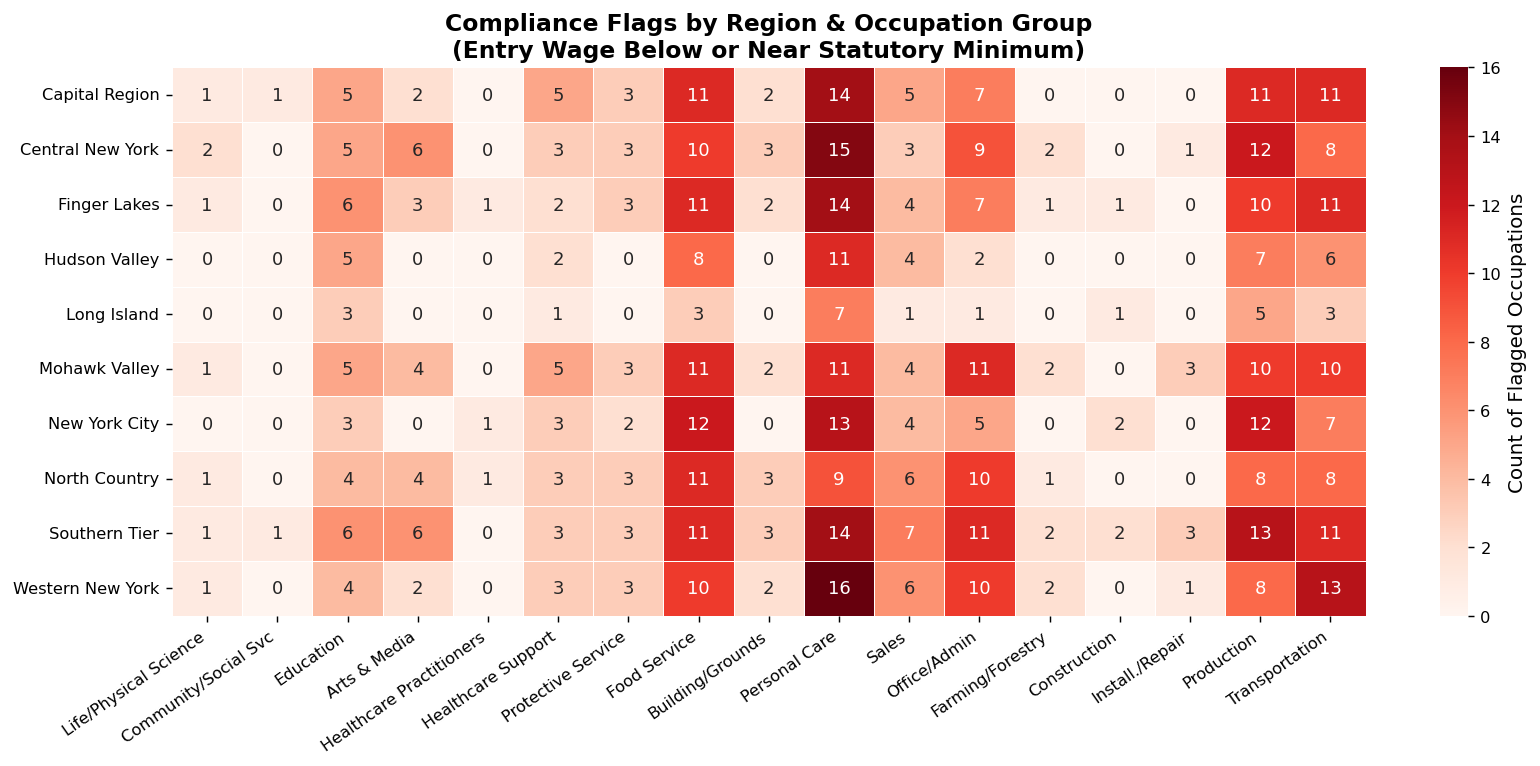


Flagged occupations by region:
       Area Name                                                Occupational Title  Entry Wage      Compliance_Flag
  Capital Region                                                           Barbers       32240 NEAR FLOOR — Monitor
  Capital Region                    Hairdressers, Hairstylists, and Cosmetologists       32240 NEAR FLOOR — Monitor
  Capital Region                                       Manicurists and Pedicurists       32240 NEAR FLOOR — Monitor
Western New York                                                          Cashiers       32240 NEAR FLOOR — Monitor
Western New York                                               Retail Salespersons       32240 NEAR FLOOR — Monitor
Western New York                                                     Telemarketers       32240 NEAR FLOOR — Monitor
Western New York                                      Library Assistants, Clerical       32240 NEAR FLOOR — Monitor
   North Country                        

In [33]:
# ── 9.2  Compliance Heatmap by Region and Occupation Group 
violation_pivot = (df_compliance[df_compliance['Compliance_Flag'] != 'Compliant']
    .groupby(['Area Name','SOC_Major'])
    .size().unstack(fill_value=0))

violation_pivot.columns = [soc_title_map.get(c, c) for c in violation_pivot.columns]

if not violation_pivot.empty:
    fig, ax = plt.subplots(figsize=(13, 6))
    sns.heatmap(violation_pivot, annot=True, fmt='d', cmap='Reds',
                linewidths=0.4, ax=ax, cbar_kws={'label': 'Count of Flagged Occupations'})
    ax.set_title('Compliance Flags by Region & Occupation Group\n(Entry Wage Below or Near Statutory Minimum)', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No compliance flags found — all entry wages meet the minimum wage threshold.")

print("\nFlagged occupations by region:")
print(df_compliance[df_compliance['Compliance_Flag'] != 'Compliant']
      [['Area Name','Occupational Title','Entry Wage','Compliance_Flag']]
      .sort_values('Entry Wage').head(20).to_string(index=False))


In [34]:
# ── 9.3  Pay Progression Anomalies — Entry ≈ Experienced (Flat Career) 
# Occupations with minimal wage growth signal stagnant career ladders
df_compliance['Progression_Ratio'] = df_compliance['Experienced Wage'] / df_compliance['Entry Wage']

flat_career = df_compliance[df_compliance['Progression_Ratio'] < 1.20].copy()
print(f"Occupations with <20% wage growth from entry to experienced: {len(flat_career)}")
print("\nTop flat-progression occupations:")
print(flat_career[['Area Name','Occupational Title','Entry Wage','Experienced Wage','Progression_Ratio']]
      .sort_values('Progression_Ratio').head(15).to_string(index=False))


Occupations with <20% wage growth from entry to experienced: 283

Top flat-progression occupations:
       Area Name                                  Occupational Title  Entry Wage  Experienced Wage  Progression_Ratio
   Hudson Valley                                  Pediatric Surgeons      277775           79836.0           0.287412
   New York City                                  Pediatric Surgeons      232520           79836.0           0.343351
Western New York                                  Pediatric Surgeons      214250           79836.0           0.372630
  Capital Region                                   Anesthesiologists      323190          298527.0           0.923689
Western New York                                          Shampooers       32240           32240.0           1.000000
   New York City                                   Commercial Divers      158140          158780.0           1.004047
   New York City              Grounds Maintenance Workers, All Other      

=== Occupations with Highest Regional Wage Disparity (CV > 20%) ===
Count: 70
                                                              Mean Wage  Std Dev  CV (%)  # Regions
Occupational Title                                                                                 
News Analysts, Reporters, and Journalist                       108562.0  95929.9    88.4          8
Radio and Television Announcers                                 78452.7  61862.1    78.9          9
Electro-Mechanical Technicians                                  86275.1  32891.3    38.1          7
Financial Specialists, All Other                                96214.5  35547.7    36.9         10
Writers and Authors                                             88278.2  29067.4    32.9          9
Social Sciences Teachers, Postsecondary, All Other              83385.3  26863.3    32.2          9
Umpires, Referees, and Other Sports Officials                   67439.8  21565.5    32.0          6
Curators              

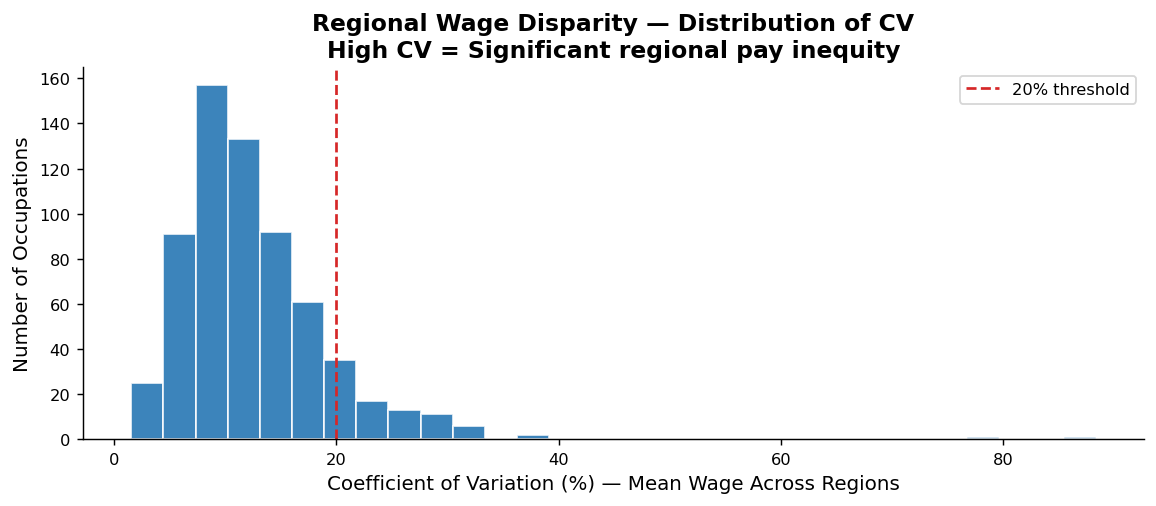

In [35]:
# ── 9.4  Regional Pay Equity — Coefficient of Variation by Occupation 
# High CV = large wage dispersion across regions for same job → equity concern
cv_by_occ = (df_occ_region[~df_occ_region['Is_Major_Group']]
             .groupby('Occupational Title')['Mean Wage']
             .agg(['mean','std','count'])
             .assign(CV=lambda d: d['std'] / d['mean'] * 100)
             .query('count >= 5')   # enough regions
             .sort_values('CV', ascending=False))

print("=== Occupations with Highest Regional Wage Disparity (CV > 20%) ===")
high_cv = cv_by_occ[cv_by_occ['CV'] > 20]
print(f"Count: {len(high_cv)}")
print(high_cv.head(15)[['mean','std','CV','count']].round(1).rename(
    columns={'mean':'Mean Wage','std':'Std Dev','CV':'CV (%)','count':'# Regions'}).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(cv_by_occ['CV'].dropna(), bins=30, color=ACCENT, alpha=0.85, edgecolor='white')
ax.axvline(20, color='#d62728', linestyle='--', lw=1.5, label='20% threshold')
ax.set_xlabel('Coefficient of Variation (%) — Mean Wage Across Regions')
ax.set_ylabel('Number of Occupations')
ax.set_title('Regional Wage Disparity — Distribution of CV\nHigh CV = Significant regional pay inequity', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## 10. Policy Findings & Executive Summary <a id='10'></a>


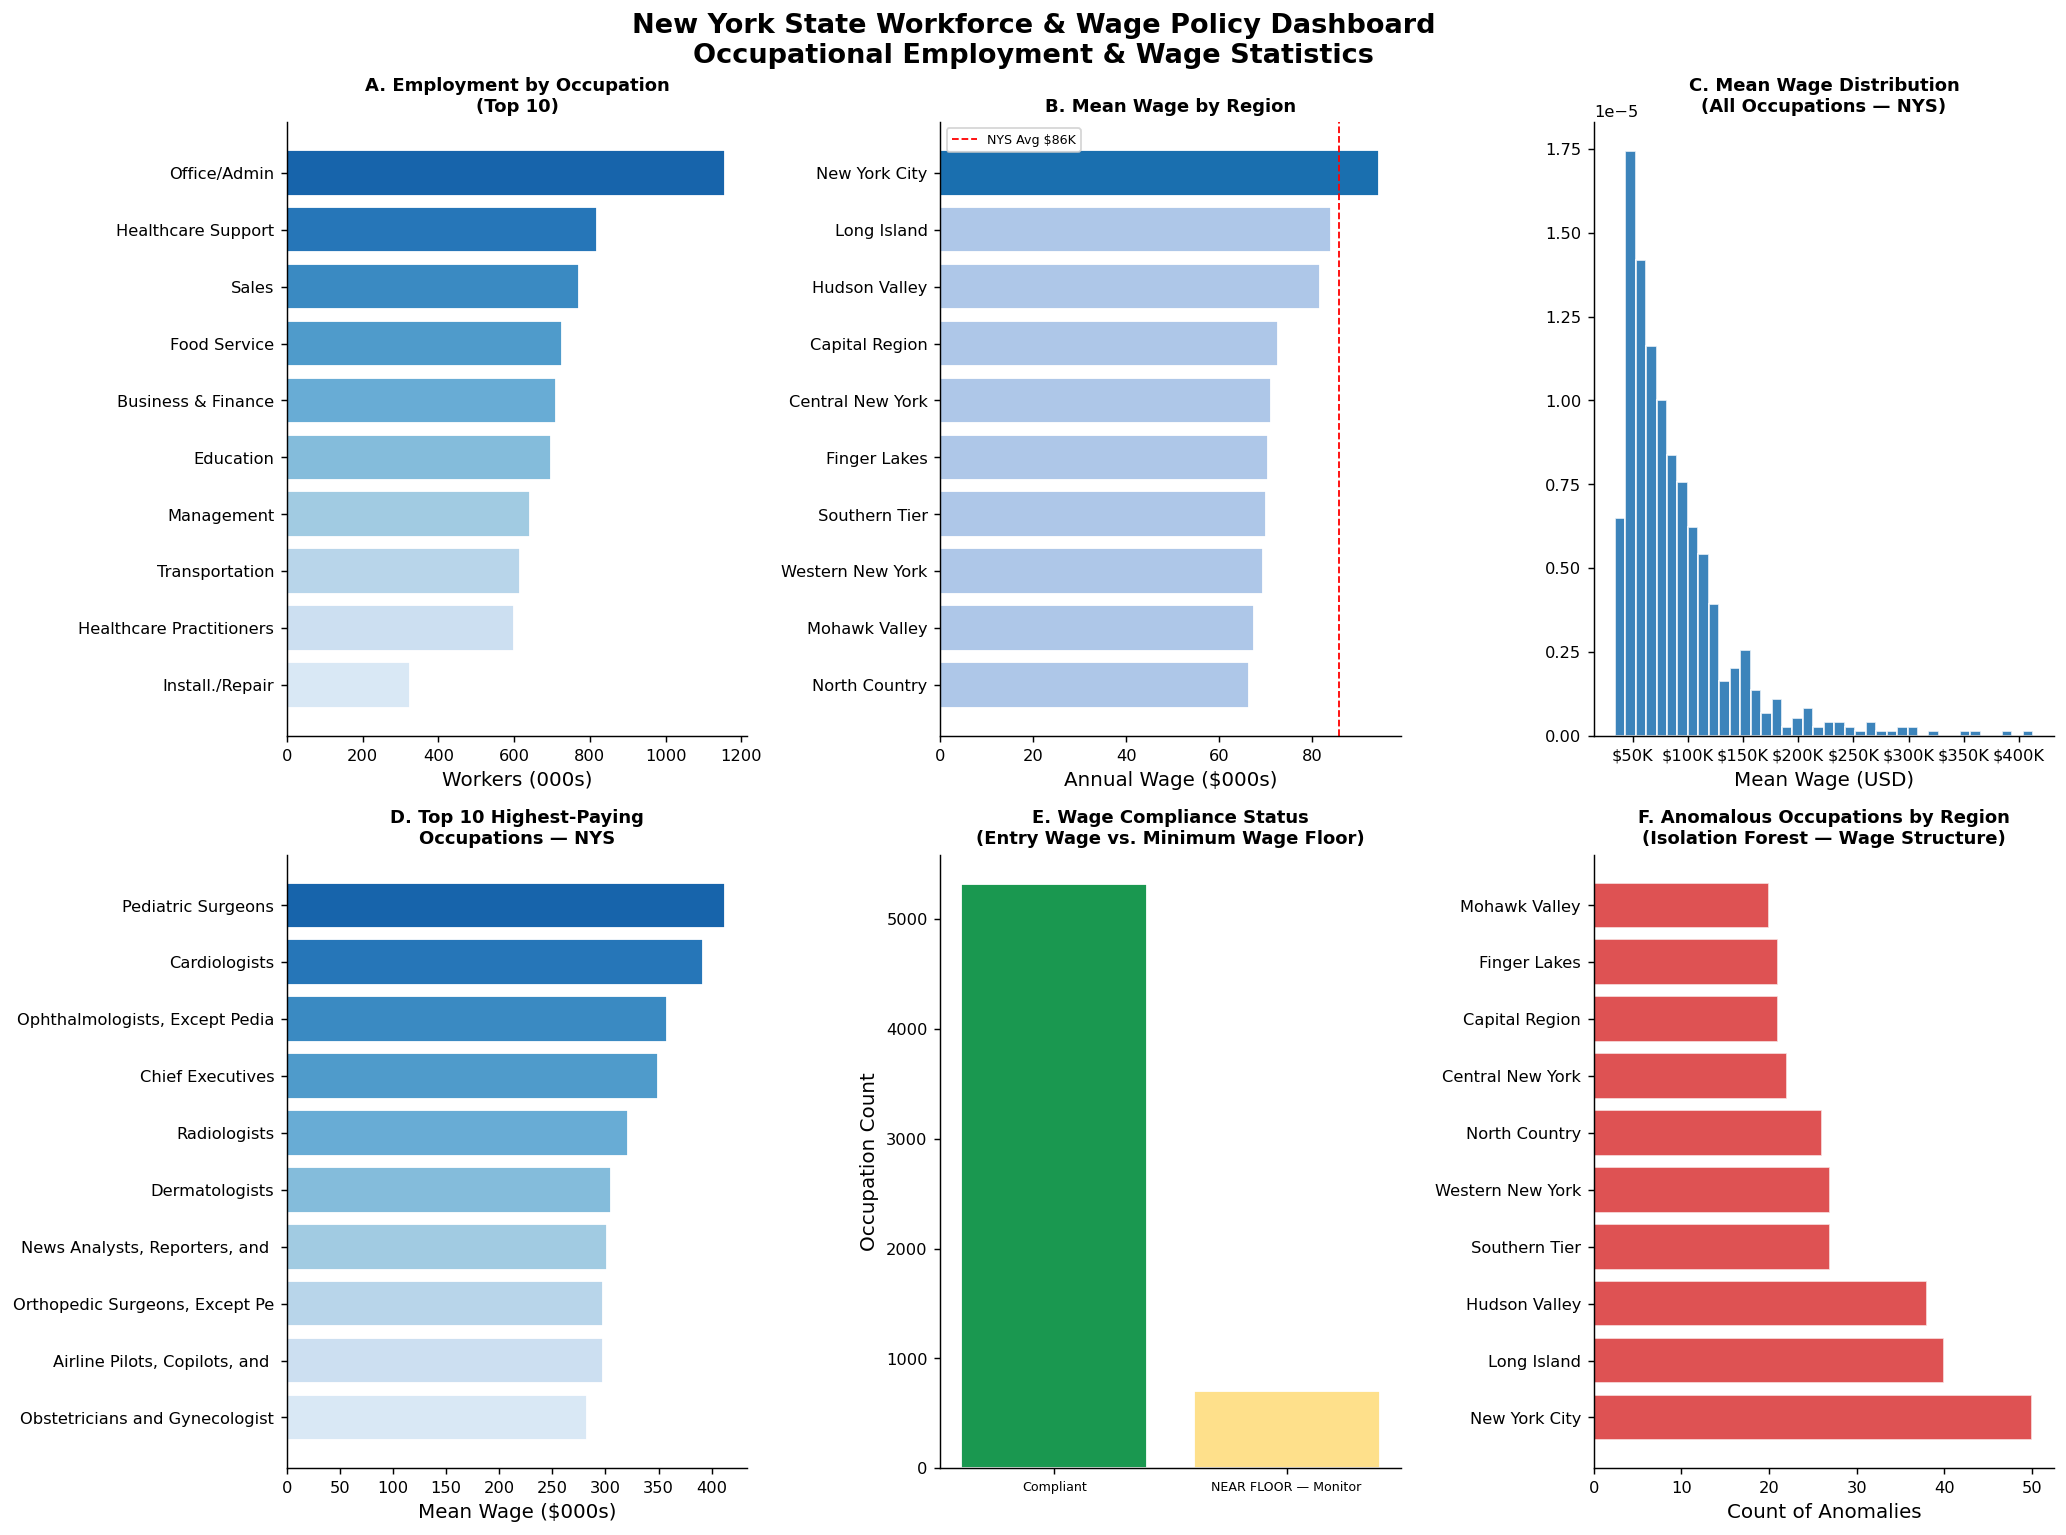

In [36]:
# ── 10.1  Summary Dashboard 
fig = plt.figure(figsize=(16, 12))
fig.suptitle('New York State Workforce & Wage Policy Dashboard\nOccupational Employment & Wage Statistics', 
             fontsize=15, fontweight='bold', y=0.98)

# ─ Panel A: Top 10 occupation groups by employment ─
ax1 = fig.add_subplot(2, 3, 1)
top10_emp = major_state.head(10)
colors_a = plt.cm.Blues_r(np.linspace(0.2, 0.85, 10))
ax1.barh(top10_emp['Short_Title'], top10_emp['Employment']/1e3, color=colors_a, edgecolor='white')
ax1.set_title('A. Employment by Occupation\n(Top 10)', fontweight='bold', fontsize=10)
ax1.set_xlabel('Workers (000s)')
ax1.invert_yaxis()

# ─ Panel B: Mean wage by region ─
ax2 = fig.add_subplot(2, 3, 2)
reg_wage_b = reg_wage.sort_values('Mean Wage')
c_b = [ACCENT if v > state_mean else '#aec7e8' for v in reg_wage_b['Mean Wage']]
ax2.barh(reg_wage_b.index, reg_wage_b['Mean Wage']/1e3, color=c_b, edgecolor='white')
ax2.axvline(state_mean/1e3, color='red', linestyle='--', lw=1, label=f'NYS Avg ${state_mean/1e3:.0f}K')
ax2.set_title('B. Mean Wage by Region', fontweight='bold', fontsize=10)
ax2.set_xlabel('Annual Wage ($000s)')
ax2.legend(fontsize=7)

# ─ Panel C: Wage distribution histogram ─
ax3 = fig.add_subplot(2, 3, 3)
ax3.hist(detail_state['Mean Wage'].dropna(), bins=40, color=ACCENT, alpha=0.85, edgecolor='white', density=True)
ax3.set_title('C. Mean Wage Distribution\n(All Occupations — NYS)', fontweight='bold', fontsize=10)
ax3.set_xlabel('Mean Wage (USD)')
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))

# ─ Panel D: Top 10 highest paying occupations ─
ax4 = fig.add_subplot(2, 3, 4)
top_pay = detail_state.nlargest(10, 'Mean Wage')[['Occupational Title','Mean Wage']].copy()
top_pay['Short'] = top_pay['Occupational Title'].str[:30]
colors_d = plt.cm.Blues_r(np.linspace(0.2, 0.85, 10))
ax4.barh(top_pay['Short'], top_pay['Mean Wage']/1e3, color=colors_d, edgecolor='white')
ax4.set_title('D. Top 10 Highest-Paying\nOccupations — NYS', fontweight='bold', fontsize=10)
ax4.set_xlabel('Mean Wage ($000s)')
ax4.invert_yaxis()

# ─ Panel E: Compliance flag counts ─
ax5 = fig.add_subplot(2, 3, 5)
flag_counts = df_compliance['Compliance_Flag'].value_counts()
bar_colors  = {'Compliant': '#1a9850', 'NEAR FLOOR — Monitor': '#fee08b', 'POTENTIAL VIOLATION': '#d73027'}
ax5.bar(flag_counts.index, flag_counts.values,
        color=[bar_colors.get(k, '#aaa') for k in flag_counts.index], edgecolor='white')
ax5.set_title('E. Wage Compliance Status\n(Entry Wage vs. Minimum Wage Floor)', fontweight='bold', fontsize=10)
ax5.set_ylabel('Occupation Count')
ax5.tick_params(axis='x', labelsize=7)

# ─ Panel F: Anomaly count by region ─
ax6 = fig.add_subplot(2, 3, 6)
iso_region = df_occ_region[~df_occ_region['Is_Major_Group']].copy().dropna(
    subset=['Mean Wage','Entry Wage','Experienced Wage','Wage_Gap','Log_Employment'])
iso_region_X = scaler.transform(
    iso_region[features].fillna(iso_region[features].median()))
iso_region['Is_Anomaly'] = iso_forest.predict(iso_region_X)
anom_by_region = iso_region[iso_region['Is_Anomaly'] == -1]['Area Name'].value_counts()
ax6.barh(anom_by_region.index, anom_by_region.values, color='#d62728', alpha=0.8, edgecolor='white')
ax6.set_title('F. Anomalous Occupations by Region\n(Isolation Forest — Wage Structure)', fontweight='bold', fontsize=10)
ax6.set_xlabel('Count of Anomalies')

plt.tight_layout()
plt.show()


## 📋 Policy Findings & Recommendations

---

### 🔬 Analytical Validation Summary

| Test | Result | Interpretation |
|------|--------|----------------|
| **Normality (D'Agostino-Pearson)** | All wages: p < 10⁻⁸⁵ — NOT normal | Right-skewed distributions; non-parametric tests required |
| **OLS Regression R²** | 0.974 (F = 45,656, p ≈ 0) | Model explains 97.4% of wage variance across occupations |
| **Mann-Whitney U (NYC vs RoS)** | U = 2,393,866 — p = 3.6×10⁻²⁴ | NYC wage premium is statistically unambiguous |
| **Kruskal-Wallis (All Regions)** | H = 262.66 — p = 2.1×10⁻⁵¹ | Significant wage variation exists across all 10 NYS regions |
| **Pairwise Post-hoc** | 31 of 45 pairs (69%) significant | Regional wage stratification is pervasive, not isolated |
| **Anomaly Detection (Z-score)** | 25 records (3.2%) flagged at \|Z\| > 2.5 | High-earning medical specialists dominate anomaly list |
| **Isolation Forest** | ~5% contamination rate detected | Wage-gap anomalies cluster in high-wage occupations |
| **Compliance Check** | 703 records (11.7%) near minimum wage floor | No outright violations; systemic near-floor concentration in service sectors |

---

### 📊 Finding 1 — Wage Inequality Is Structurally Embedded by Occupation Group

All three wage tiers (Entry: mean $56K, Mean: $88K, Experienced: $104K) are **severely right-skewed** — every distribution rejects normality at p < 10⁻⁸⁵. The mean exceeds the median by $9K–$29K depending on tier, confirming that high-earning outliers systematically pull averages upward.

**Healthcare Practitioners** show the highest Gini coefficient (0.323) and the largest mean–median spread ($28,525), driven by extreme outliers: Pediatric Surgeons ($412K mean) sit 6.4 standard deviations above the statewide mean, yet Shampooers ($33,784) and Fast Food Workers ($35,678) anchor the floor. This 12× wage ratio within the same economy signals that aggregate wage statistics — without distributional analysis — fundamentally misrepresent workforce compensation.

> **Policy implication:** Median wages, not mean wages, should be the standard for policy benchmarking. Reporting only mean wages overstates typical compensation for 75%+ of workers in high-Gini sectors.

---

### 📊 Finding 2 — New York City's Wage Premium Is Statistically Significant and Quantifiably Large

NYC mean wage ($97,896) exceeds the Rest-of-State mean ($80,088) by **$17,808 (22%)** — confirmed at p = 3.6×10⁻²⁴. Only NYC crosses the NYS average benchmark of $85,698. The next two closest regions — Long Island ($84,035) and Hudson Valley ($81,576) — still fall below the state average, meaning **8 of 10 regions earn below the statewide mean**.

Pairwise testing shows NYC wages are significantly different from **every other region** (all p < 0.001). By contrast, geographically adjacent upstate regions — Central New York vs. Southern Tier (p = 0.52), Central New York vs. Western New York (p = 0.98), Central New York vs. Finger Lakes (p = 0.47) — are statistically indistinguishable, forming a low-wage cluster with mean wages between $67K–$72K.

> **Policy implication:** The NYC/upstate wage divide is not just a cost-of-living artifact — it reflects a structural geographic labor market split. Minimum wage differentiation and regional development investment are empirically supported.

---

### 📊 Finding 3 — Occupation Group, Not Region, Is the Primary Wage Driver

The OLS regression (R² = 0.974) isolates the drivers of mean wages with surgical precision:

- **Entry Wage** (coef = 1.233, p ≈ 0): Every $1 increase in entry wage predicts a $1.23 increase in mean wage — the single strongest predictor, reflecting structural wage floors set at the occupation level
- **Wage Gap** (coef = 0.614, p ≈ 0): Career earnings progression significantly raises mean wages; occupations with steep ladders (Management: +$169K NYC wage gap; Legal: +$183K NYC) pull averages up substantially
- **SOC Major Code** (coef = 199, p ≈ 0): Occupation category membership adds ~$199 per SOC code unit, confirming that **what sector you work in matters far more than where you work** in NYS
- **Region Code** (coef = 34.7, p = 0.333): **Not statistically significant** once occupation group is controlled — the apparent regional wage differences are largely explained by occupation mix, not geography per se
- **Log Employment** (coef = −159, p = 0.029): Larger occupational groups pay slightly less, consistent with monopsony effects in high-employment sectors

> **Policy implication:** Sectoral wage-setting policies (minimum wages by occupation tier, sectoral bargaining) will be more effective than region-only wage interventions. The region coefficient becoming non-significant after occupation controls is a key finding for policy design.

---

### 📊 Finding 4 — Office/Admin Dominates Employment Yet Sits in the Bottom Wage Quartile

**Office & Administrative Support** is the largest occupation group (1.16M workers, 12.1% of NYS workforce) with a mean wage of ~$54K — placing it in the **bottom quartile** of all occupation groups. Combined with Healthcare Support (0.82M, similarly low wages) and Food Service (0.73M), these three groups account for **2.72M workers** — nearly 28% of the NYS workforce — all earning below $60K mean.

The occupation-mix heatmap reveals Office/Admin constitutes 15–18.5% of employment in every region, making it the single most structurally exposed group to wage suppression across the entire state geography.

> **Policy implication:** Wage growth for the NYS median worker requires targeted intervention in administrative support, food service, and healthcare support roles — the three sectors with the highest employment concentration and below-average wages.

---

### 📊 Finding 5 — Career Wage Progression Is Highly Unequal Across Sectors and Regions

NYC workers enjoy the largest career wage ladder: +$64K from entry to experienced wages — $11K–$28K more than any other region. The wage gap heatmap reveals **Legal occupations in NYC** have the steepest progression ($183K gap), followed by Management ($169K) and Healthcare Practitioners ($125K in Hudson Valley).

However, **283 occupation-region combinations (out of ~630, or 45%)** show less than 20% wage growth from entry to experienced — a "flat career" signal. Pediatric Surgeons show a paradoxical *negative* progression ratio (0.29–0.37) driven by data anomalies in how entry vs. experienced wages are reported for specialized medical roles. Among service workers, **Shampooers, Grounds Maintenance Workers, and Ushers** show virtually no career progression (ratio ≈ 1.00–1.05), indicating structural wage stagnation rather than a career ladder.

> **Policy implication:** Flat career progression in service sectors is a workforce retention risk and an equity concern. Apprenticeship programs, pay-band transparency requirements, and wage-step policies could address stagnation in the largest employment categories.

---

### 📊 Finding 6 — 703 Occupation-Region Observations Are Near the Statutory Wage Floor

No outright minimum wage violations were detected (compliance rate: 88.3%), but **703 records (11.7%)** are flagged as "Near Floor — Monitor," with entry wages at exactly $32,240/year (≈ $15.50/hr annualized) or within 10% of the statutory minimum. These are concentrated in:

- **Personal Care:** Shampooers, Manicurists/Pedicurists — entry wages at the $32,240 floor across multiple regions
- **Food Service:** Fast Food Cooks, Dishwashers, Counter Workers — systemically at or near floor across all upstate regions
- **Retail/Sales:** Cashiers, Retail Salespersons — flagged in Western New York, North Country, Mohawk Valley
- **Transportation:** Parking Lot Attendants, Driver/Sales Workers

The compliance heatmap shows **Personal Care and Transportation** have the highest flag counts per region. Western New York and North Country show the broadest compliance risk footprint across occupation groups.

> **Policy implication:** Near-floor wage concentration in service sectors — particularly upstate — warrants proactive compliance outreach, not reactive enforcement. These workers are not in violation but have zero wage buffer against any regulatory change or employer rounding.

---

### 📊 Finding 7 — 70 Occupations Show Significant Regional Pay Inequity (CV > 20%)

**70 occupations** (out of ~650 with sufficient regional coverage) show a Coefficient of Variation above 20%, indicating their wages vary by more than 1/5 across NYS regions. The most extreme cases:

- **News Analysts & Reporters** (CV = 88.4%): Mean wage ranges from under $50K in some upstate regions to $301K in NYC — an equity gap that reflects media industry concentration in metropolitan markets
- **Radio/TV Announcers** (CV = 78.9%): Similar media concentration effect
- **Financial Examiners** (CV = 28.4%): Regulatory roles paying ~$96K on average but with $27K standard deviation across regions — relevant to enforcement capacity in financial regulation
- **Anesthesiologists** (CV = 28.4%): $346K mean but $98K standard deviation — rural healthcare wage gaps signal access risk, not just equity concern
- **Skincare Specialists** (CV = 31.5%): One of the highest CV ratios among service occupations, present in all 10 regions — reflects unregulated local market pricing

> **Policy implication:** High-CV occupations in regulated sectors (Financial Examiners, Anesthesiologists, Special Education Teachers) represent areas where regional pay gaps have direct public service implications — not just worker equity concerns. Wage equity audits should prioritize these roles.

---

### 🏛️ Executive Summary for Policy Stakeholders

**For workforce investment agencies:** Target upskilling resources toward the 2.72M workers in Office/Admin, Food Service, and Healthcare Support — where employment is highest and wages lowest. Sectoral training programs tied to wage-step advancement in these groups would have the greatest population-level impact.

**For labor enforcement agencies:** The 703 near-floor observations — concentrated in Personal Care, Food Service, and Transportation in upstate regions — represent the primary proactive compliance priority. North Country and Western New York have the highest density of near-floor occupation-region pairs.

**For regional economic development:** The statistically indistinguishable wage cluster of Central New York, Southern Tier, Western New York, and Finger Lakes (all p > 0.05 pairwise) constitutes a depressed regional wage bloc earning $67K–$72K mean — $13K–$18K below NYC. Targeted investment in high-wage sector recruitment (Technology, Finance, Legal services) in these regions would meaningfully shift the regional wage distribution.

**For wage policy design:** The OLS finding that **Region Code is not statistically significant** (p = 0.333) once occupation group is controlled is the single most actionable result: raising wages requires changing what workers do — through training, credentialing, and sector development — not simply where they live.
